In [2]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

# Import custom modules
import data_loader
import cell_filter
import diff_expression
import marker_selection
import visualization
# from varibow import varibow

# Configure plotting
sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=100, frameon=False, figsize=(8, 6))
sns.set_style('whitegrid')

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

## 1. Load Allen Brain Map Data

Download data from: https://celltypes.brain-map.org/rnaseq/mouse/v1-alm

Required files:
- Cell metadata (annotations, layer, cluster assignments)
- Expression matrix (TPM or counts)

In [69]:
# Paths to Allen Brain Map VISp SMART-seq data
DATA_DIR = '/mnt/nasquatch/data/RNAseq/allenV1_SMART-seq'

expression_path = f'{DATA_DIR}/mouse_VISp_2018-06-14_exon-matrix.csv'
metadata_path = f'{DATA_DIR}/mouse_VISp_2018-06-14_samples-columns.csv'
genes_path = f'{DATA_DIR}/mouse_VISp_2018-06-14_genes-rows.csv'

# Cache filtered results to disk — re-runs load in seconds instead of minutes
cell_filter.set_cache_dir(f'{DATA_DIR}/cache')

# Superficial-layer GABAergic cells: all brain_subregion values spanning L1–L4.
# The UMAP cache (umap_gaba.csv) was computed on all GABAergic cells, so the
# coordinates for this subset are already present and will be sliced correctly.
SUPERFICIAL_LAYERS = ['L1', 'L1-L2/3', 'L1-L4', 'L1-L6', 'L2/3', 'L2/3-L4', 'L4']

adata_l23_inh = data_loader.load_allen_filtered(
    metadata_path=metadata_path,
    expression_path=expression_path,
    target_class='GABAergic',
    target_layers=SUPERFICIAL_LAYERS,
    genes_path=genes_path,
    layer_name='counts',
    obsm_paths={'X_umap': f'{DATA_DIR}/cache/umap_gaba.csv'},
)
adata_l23_inh

if 'X_umap' not in adata_l23_inh.obsm:
    sc.pp.normalize_total(adata_l23_inh)
    sc.pp.log1p(adata_l23_inh)
    sc.pp.pca(adata_l23_inh)
    sc.pp.neighbors(adata_l23_inh)
    sc.tl.umap(adata_l23_inh)

    pd.DataFrame(
        adata_l23_inh.obsm['X_umap'],
        index=adata_l23_inh.obs_names,
        columns=['umap_1', 'umap_2'],
    ).to_csv(f'{DATA_DIR}/cache/umap_gaba.csv')

Loading metadata from /mnt/nasquatch/data/RNAseq/allenV1_SMART-seq/mouse_VISp_2018-06-14_samples-columns.csv...
Loaded metadata: 15413 cells × 49 columns
Key columns: ['class', 'subclass', 'cluster']
Metadata filter: 3215 of 15413 cells selected (class='GABAergic', layers=['L1', 'L1-L2/3', 'L1-L4', 'L1-L6', 'L2/3', 'L2/3-L4', 'L4'])
Loading expression matrix from /mnt/nasquatch/data/RNAseq/allenV1_SMART-seq/mouse_VISp_2018-06-14_exon-matrix.csv...
  Reading 3215 of 15413 cell columns...
Loaded expression: 3215 cells × 45768 genes
Creating AnnData with 3215 cells

Cell classes: 1
class
GABAergic    3215
Name: count, dtype: int64
Loading obsm embeddings...
  obsm['X_umap']: loaded shape (3215, 2)


In [70]:
# Explore the filtered dataset
print("Available metadata columns:")
print(adata_l23_inh.obs.columns.tolist())

print("\n" + "="*50)
print("Layer 2/3 GABAergic cell type annotations:")
print("="*50)

print("\nSubclass distribution:")
print(adata_l23_inh.obs['subclass'].value_counts())

print("\nCluster distribution:")
print(adata_l23_inh.obs['cluster'].value_counts())

Available metadata columns:
['sample_id', 'sample_type', 'organism', 'donor', 'sex', 'age_days', 'eye_condition', 'genotype', 'driver_lines', 'reporter_lines', 'brain_hemisphere', 'brain_region', 'brain_subregion', 'injection_label_direction', 'injection_primary', 'injection_secondary', 'injection_tract', 'injection_material', 'injection_exclusion_criterion', 'facs_date', 'facs_container', 'facs_sort_criteria', 'rna_amplification_set', 'library_prep_set', 'library_prep_avg_size_bp', 'seq_name', 'seq_tube', 'seq_batch', 'total_reads', 'percent_exon_reads', 'percent_intron_reads', 'percent_intergenic_reads', 'percent_rrna_reads', 'percent_mt_exon_reads', 'percent_reads_unique', 'percent_synth_reads', 'percent_ecoli_reads', 'percent_aligned_reads_total', 'complexity_cg', 'genes_detected_cpm_criterion', 'genes_detected_fpkm_criterion', 'tdt_cpm', 'gfp_cpm', 'class', 'subclass', 'cluster', 'confusion_score', 'cluster_correlation', 'core_intermediate_call']

Layer 2/3 GABAergic cell type ann

          n_cells  percentage
subclass                     
Vip          1327       41.28
Lamp5         981       30.51
Pvalb         513       15.96
Sst           315        9.80
Sncg           66        2.05
Serpinf1        7        0.22
Meis2           6        0.19


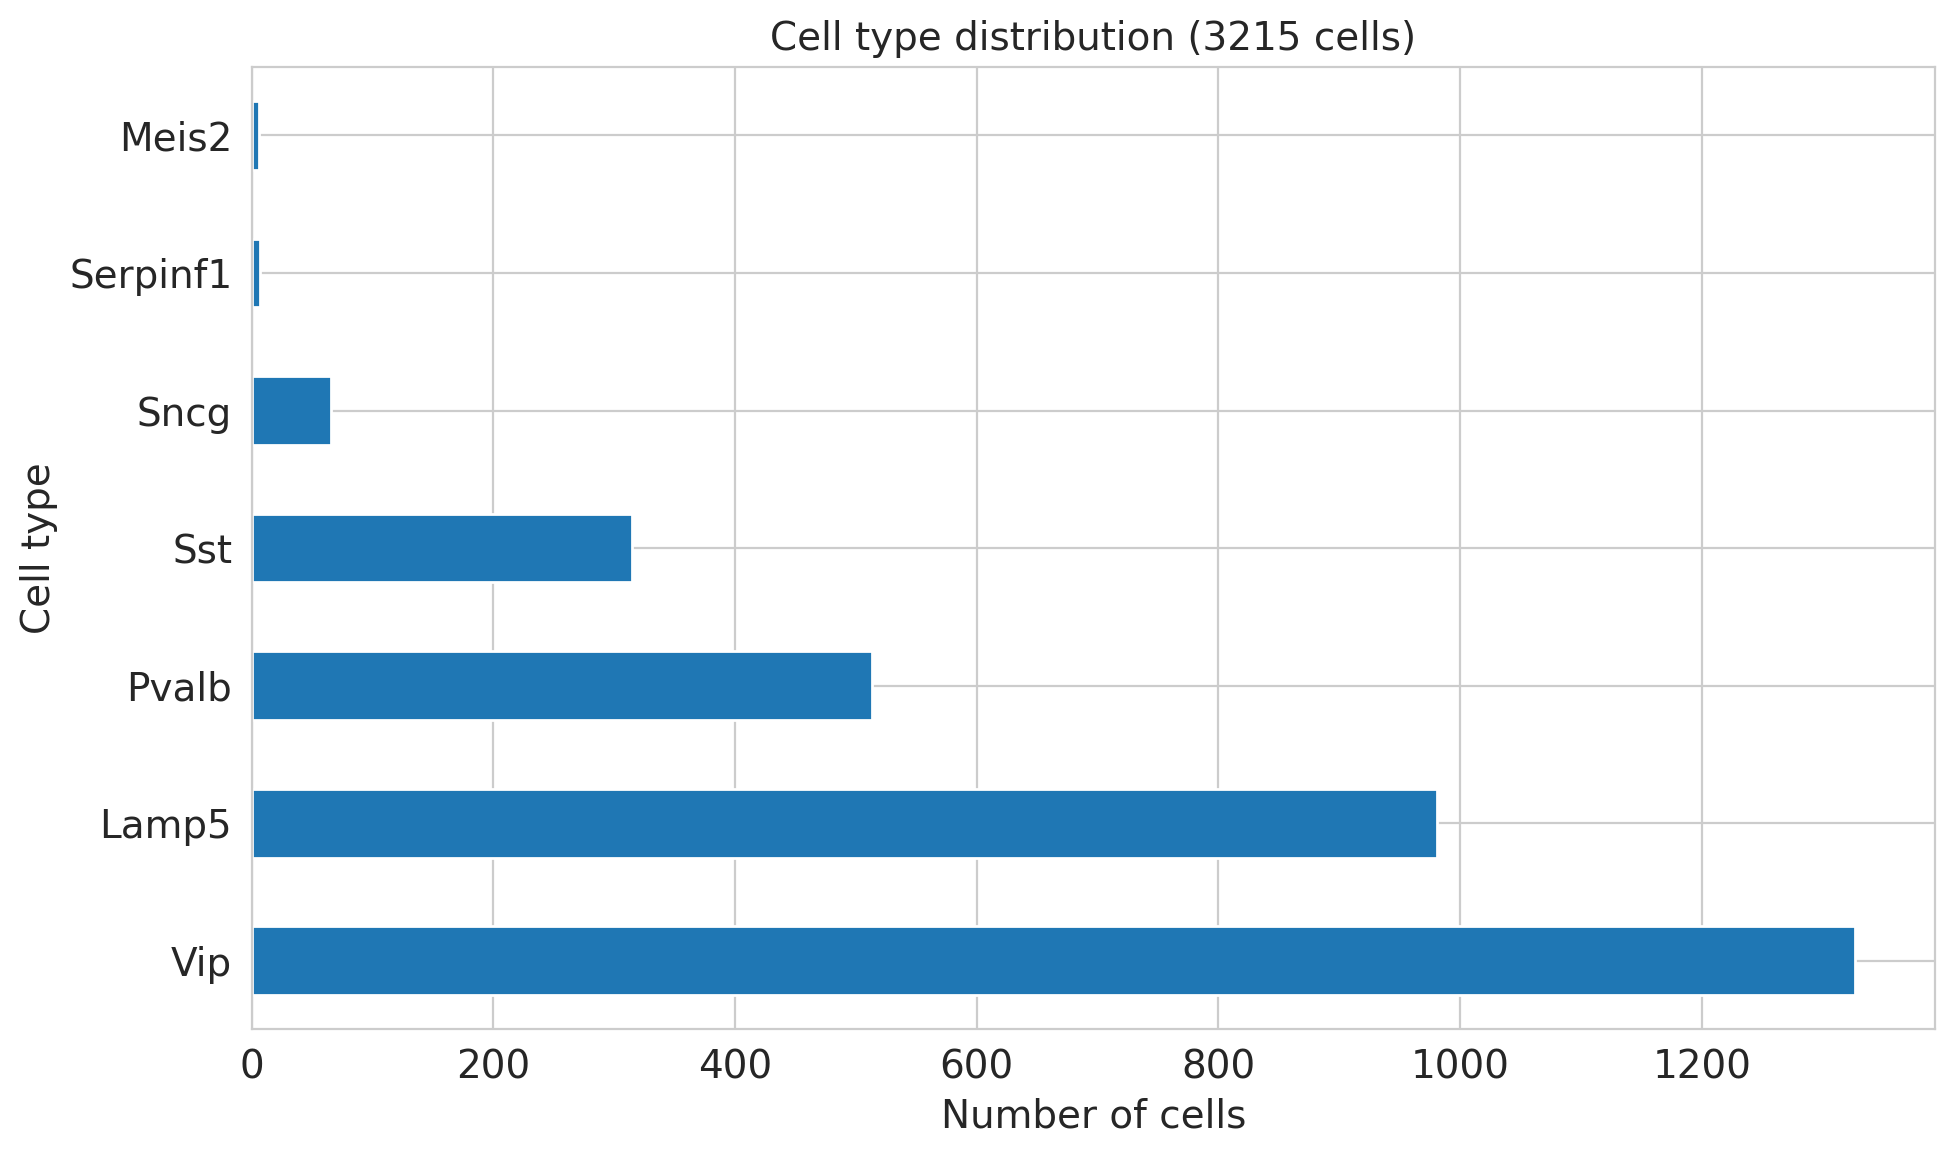

In [71]:
# Cell-level filtering already applied during load (GABAergic + L2/3).
# Summarize subclass composition of the loaded dataset.
summary = cell_filter.get_cell_type_summary(adata_l23_inh, groupby='subclass')
print(summary)

fig = visualization.plot_celltype_distribution(adata_l23_inh, groupby='subclass')
plt.show()

In [72]:
# Filter low-expressed genes
# With count data, require at least 1 count in 10+ cells
# adata_l23_inh = cell_filter.filter_expressed_genes(
#     adata_l23_inh,
#     min_cells=10,
#     min_counts=1.0,
# )

# # # Optional: Filter to high-quality cells only
# # adata_l23_inh = cell_filter.filter_high_quality(adata_l23_inh, exclude_no_class=True)


          n_cells  percentage
subclass                     
Vip          1327       41.28
Lamp5         981       30.51
Pvalb         513       15.96
Sst           315        9.80
Sncg           66        2.05
Serpinf1        7        0.22
Meis2           6        0.19


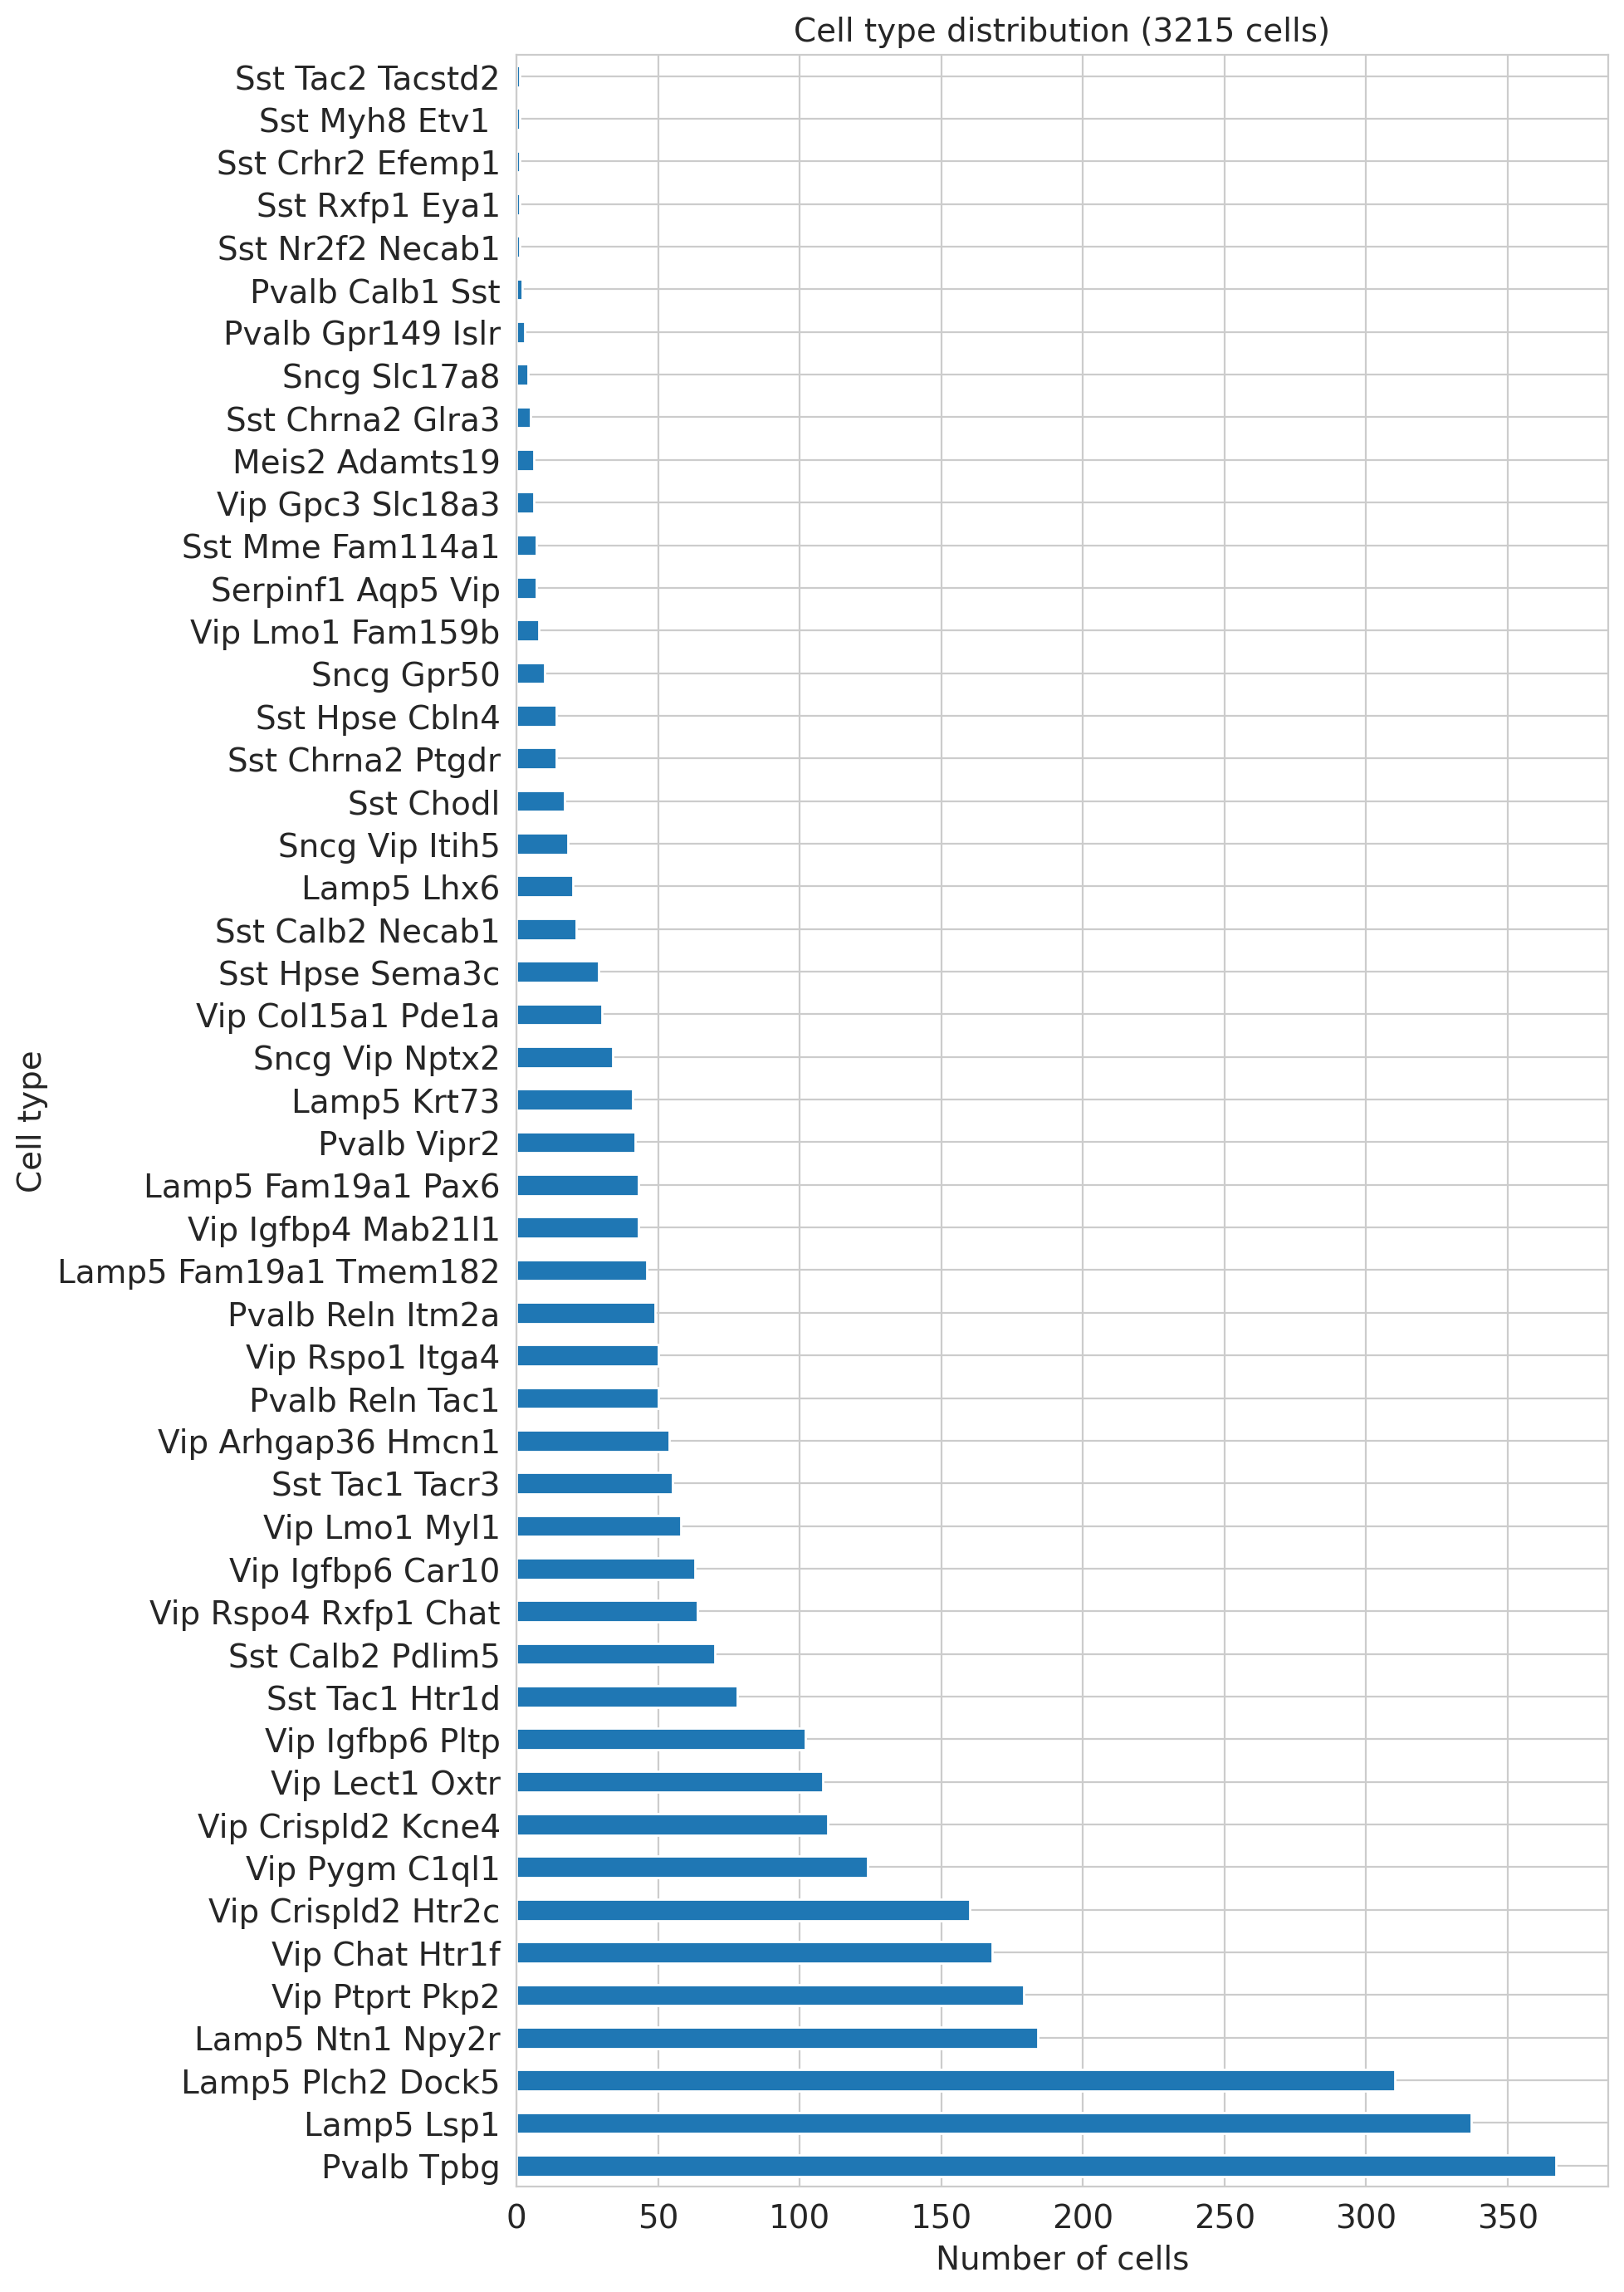

In [73]:
# Cell-level filtering already applied during load (GABAergic + L2/3).
# Summarize subclass composition of the loaded dataset.
summary = cell_filter.get_cell_type_summary(adata_l23_inh, groupby='subclass')
print(summary)

fig = visualization.plot_celltype_distribution(adata_l23_inh, groupby='cluster')
fig.set_size_inches(10,16)
# plt.show()

Retained 3162 cells in 36 clusters (14 cluster(s) with <10 cells excluded)


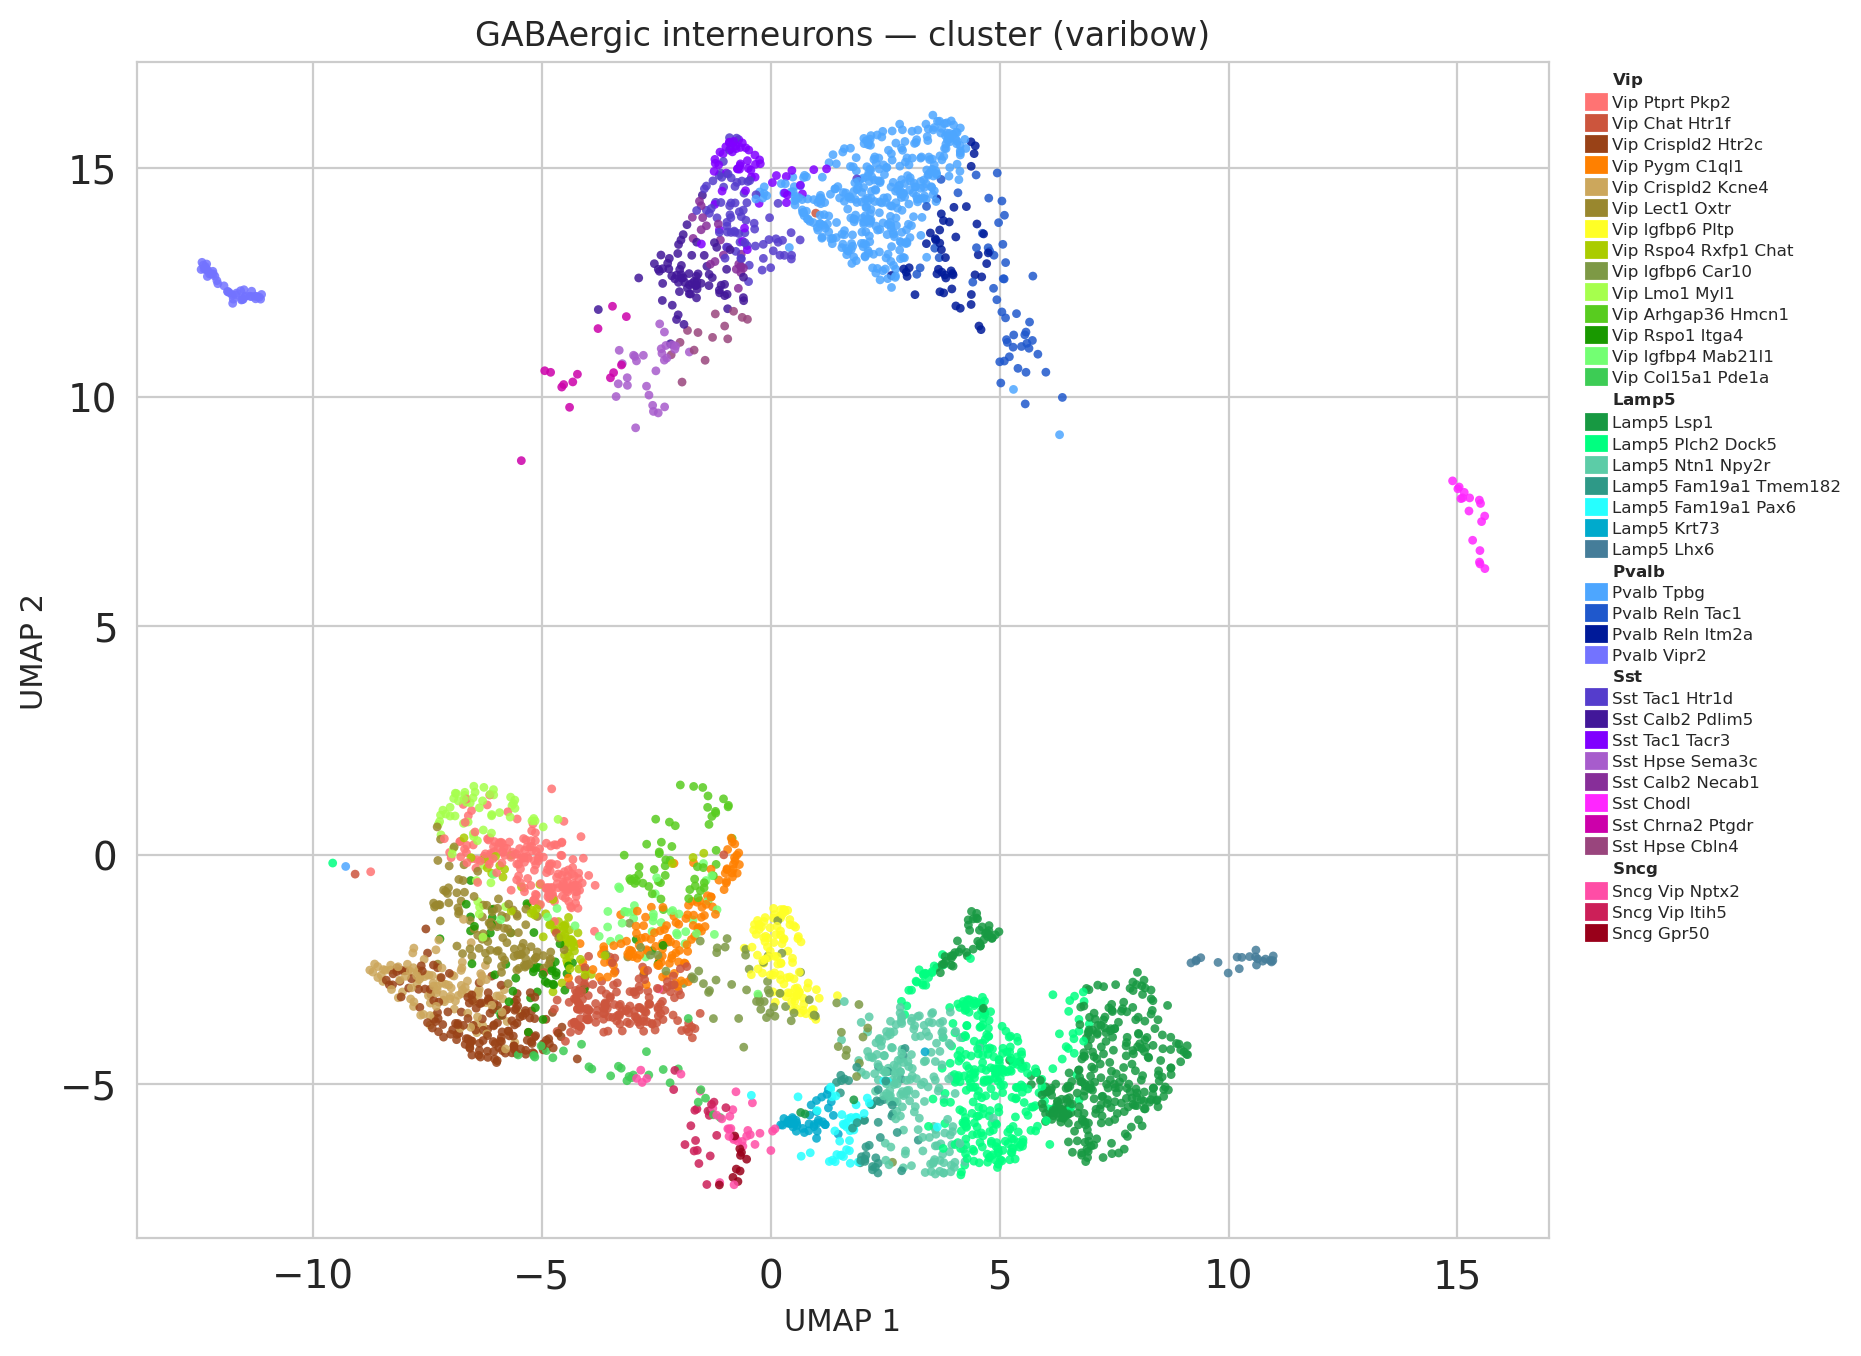

In [ ]:
import matplotlib.patches as mpatches
import numpy as np
from visualization import varibow

obs = adata_l23_inh.obs[['subclass', 'cluster']].copy()

# ── 0. Drop clusters with <10 observations ────────────────────────────────────
cluster_counts = obs['cluster'].value_counts()
valid_clusters = cluster_counts[cluster_counts >= 10].index
n_dropped = (cluster_counts < 10).sum()
obs = obs[obs['cluster'].isin(valid_clusters)]
print(f"Retained {len(obs)} cells in {len(valid_clusters)} clusters "
      f"({n_dropped} cluster(s) with <10 cells excluded)")

# ── 1. Color-axis ordering ────────────────────────────────────────────────────
# Subclasses ordered by descending cell count; clusters likewise within each subclass.
subclass_order = obs['subclass'].value_counts().index.tolist()
cluster_to_subclass = obs.groupby('cluster')['subclass'].first()

cluster_order = []
for subclass_name in subclass_order:
    clusters_in_subclass = (
        obs.loc[obs['subclass'] == subclass_name, 'cluster']
        .value_counts().index.tolist()
    )
    cluster_order.extend(clusters_in_subclass)

# ── 2. varibow palette ────────────────────────────────────────────────────────
palette = varibow(len(cluster_order))
cluster_color = {c: palette[i] for i, c in enumerate(cluster_order)}

# ── 3. Align UMAP positions to filtered cell order ────────────────────────────
# obs is a subset of adata_l23_inh.obs; get_indexer maps cell IDs → positional
# indices into the obsm array so colors and coordinates stay in sync.
cell_positions = adata_l23_inh.obs_names.get_indexer(obs.index)
umap = adata_l23_inh.obsm['X_umap'][cell_positions]
cell_colors = np.array(obs['cluster'].map(cluster_color).tolist())

rng = np.random.default_rng(42)
idx = rng.permutation(len(umap))

# ── 4. Scatter ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(
    umap[idx, 0], umap[idx, 1],
    c=cell_colors[idx],
    s=10, linewidths=0, alpha=0.85, rasterized=True,
)
ax.set_xlabel('UMAP 1', fontsize=11)
ax.set_ylabel('UMAP 2', fontsize=11)
ax.set_title('GABAergic interneurons — cluster (varibow)', fontsize=12)
ax.set_aspect('equal')

# ── 5. Legend grouped by subclass, in color-axis order ───────────────────────
handles = []
for subclass_name in subclass_order:
    handles.append(mpatches.Patch(
        facecolor='none', edgecolor='none', label=f'$\\bf{{{subclass_name}}}$'
    ))
    for cluster_name in [c for c in cluster_order if cluster_to_subclass[c] == subclass_name]:
        handles.append(mpatches.Patch(color=cluster_color[cluster_name], label=cluster_name))

ax.legend(
    handles=handles,
    bbox_to_anchor=(1.02, 1), loc='upper left',
    fontsize=6, frameon=False,
    handlelength=1.2, handleheight=1.0,
    borderpad=0, labelspacing=0.3,
)

plt.tight_layout()
plt.show()

In [77]:
## Step 2 — Per-cluster median transcriptomes (reference centroids)

# ── Same quality threshold as the plot ───────────────────────────────────────
cluster_counts = adata_l23_inh.obs['cluster'].value_counts()
valid_clusters = cluster_counts[cluster_counts >= 10].index
obs_ref = adata_l23_inh.obs[adata_l23_inh.obs['cluster'].isin(valid_clusters)]

# ── Cluster order: subclass desc by count, then cluster desc within subclass ──
subclass_order_ref = obs_ref['subclass'].value_counts().index.tolist()
cluster_to_subclass_ref = obs_ref.groupby('cluster')['subclass'].first()

cluster_order_ref = []
for subclass_name in subclass_order_ref:
    clusters_in_subclass = (
        obs_ref.loc[obs_ref['subclass'] == subclass_name, 'cluster']
        .value_counts().index.tolist()
    )
    cluster_order_ref.extend(clusters_in_subclass)

# ── Compute median counts per cluster ─────────────────────────────────────────
X = adata_l23_inh.layers['counts']
if hasattr(X, 'toarray'):
    X = X.toarray()

medians = {}
for cluster in cluster_order_ref:
    mask = (adata_l23_inh.obs['cluster'] == cluster).values
    medians[cluster] = np.median(X[mask], axis=0)

# ref_medians: (n_clusters × n_genes), rows in cluster_order_ref order
ref_medians = pd.DataFrame(
    medians,
    index=adata_l23_inh.var_names,
).T.loc[cluster_order_ref]

# ── Gene ID → symbol lookup from adata.var ────────────────────────────────────
id_to_symbol = adata_l23_inh.var['gene_symbol']

print(f"Reference centroids: {ref_medians.shape[0]} clusters × {ref_medians.shape[1]} genes\n")
print(f"{'Cluster':<35} {'Subclass':<12} {'N cells':>7}  Top-5 expressed genes")
print("─" * 95)
for cluster in cluster_order_ref:
    top5_ids = ref_medians.loc[cluster].nlargest(5).index
    top5 = id_to_symbol.loc[top5_ids].tolist()
    print(f"{cluster:<35} {cluster_to_subclass_ref[cluster]:<12} {cluster_counts[cluster]:>7}  {', '.join(top5)}")

Reference centroids: 36 clusters × 45768 genes

Cluster                             Subclass     N cells  Top-5 expressed genes
───────────────────────────────────────────────────────────────────────────────────────────────
Vip Ptprt Pkp2                      Vip              179  Vip, Malat1, Calm2, Snhg11, Snap25
Vip Chat Htr1f                      Vip              168  Vip, Malat1, Tac2, Calm2, Crh
Vip Crispld2 Htr2c                  Vip              160  Vip, Malat1, Calm2, Crh, Tac2
Vip Pygm C1ql1                      Vip              124  Vip, Malat1, Calm2, Synpr, Tspan7
Vip Crispld2 Kcne4                  Vip              110  Vip, Malat1, Calm2, Snap25, Atp1b1
Vip Lect1 Oxtr                      Vip              108  Vip, Malat1, Calm2, Snhg11, Snap25
Vip Igfbp6 Pltp                     Vip              102  Malat1, Penk, Calm2, Nap1l5, Rtn1
Vip Rspo4 Rxfp1 Chat                Vip               64  Vip, Malat1, Synpr, Calm2, Tac2
Vip Igfbp6 Car10                    Vip        

Cosine similarity — full gene panel (45,768 genes, 3,162 cells)
  Cluster-level accuracy:  0.698  (2206 / 3162)
  Subclass-level accuracy: 0.965  (3051 / 3162)

Cluster                             Subclass         N     Acc
─────────────────────────────────────────────────────────────────
Vip Ptprt Pkp2                      Vip            179   0.525
Vip Chat Htr1f                      Vip            168   0.661
Vip Crispld2 Htr2c                  Vip            160   0.669
Vip Pygm C1ql1                      Vip            124   0.589
Vip Crispld2 Kcne4                  Vip            110   0.627
Vip Lect1 Oxtr                      Vip            108   0.565
Vip Igfbp6 Pltp                     Vip            102   0.902
Vip Rspo4 Rxfp1 Chat                Vip             64   0.500
Vip Igfbp6 Car10                    Vip             63   0.571
Vip Lmo1 Myl1                       Vip             58   0.724
Vip Arhgap36 Hmcn1                  Vip             54   0.704
Vip Rspo1 Itga4  

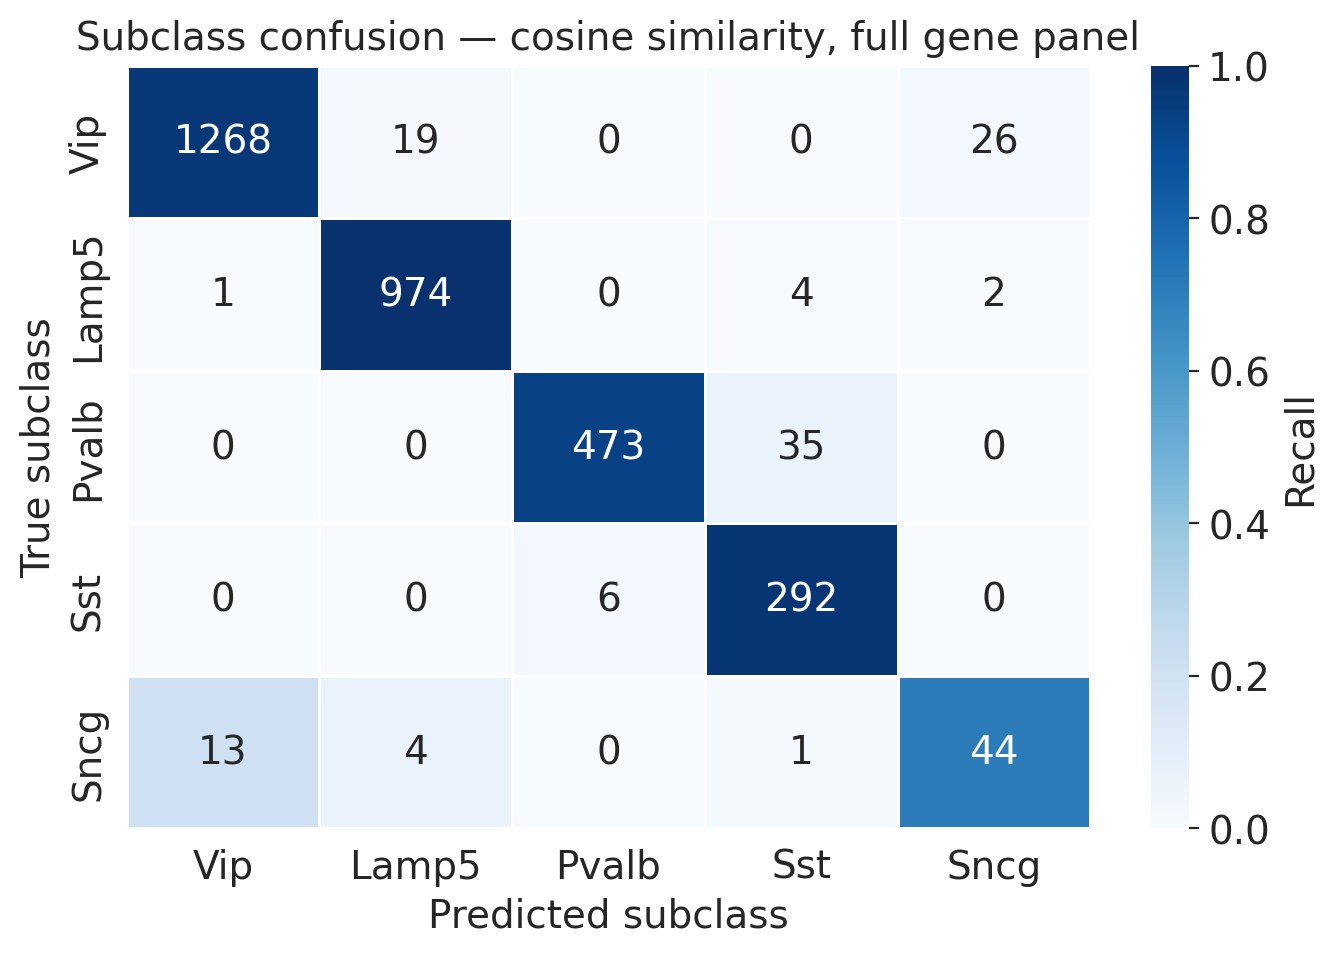

In [78]:
## Mapping metric validation — cosine similarity, full gene panel

from sklearn.metrics.pairwise import cosine_similarity

# X (dense, all cells × all genes) and cluster_order_ref / ref_medians are
# defined in the centroid cell above.

# ── Query: cells belonging to valid clusters ──────────────────────────────────
valid_cell_mask = adata_l23_inh.obs['cluster'].isin(valid_clusters).values
X_query       = X[valid_cell_mask]                                          # (n_cells × n_genes)
true_clusters  = adata_l23_inh.obs.loc[valid_cell_mask, 'cluster'].values
true_subclass  = adata_l23_inh.obs.loc[valid_cell_mask, 'subclass'].values

# ── Cosine similarity against all cluster centroids ───────────────────────────
# sim: (n_cells × n_clusters)
sim = cosine_similarity(X_query, ref_medians.values)

pred_indices   = sim.argmax(axis=1)
pred_clusters  = np.array([cluster_order_ref[i] for i in pred_indices])
pred_subclass  = np.array([cluster_to_subclass_ref[c] for c in pred_clusters])

# ── Accuracy ──────────────────────────────────────────────────────────────────
cluster_acc  = (pred_clusters == true_clusters).mean()
subclass_acc = (pred_subclass == true_subclass).mean()

print(f"Cosine similarity — full gene panel ({X_query.shape[1]:,} genes, {X_query.shape[0]:,} cells)")
print(f"  Cluster-level accuracy:  {cluster_acc:.3f}  ({(pred_clusters == true_clusters).sum()} / {len(true_clusters)})")
print(f"  Subclass-level accuracy: {subclass_acc:.3f}  ({(pred_subclass  == true_subclass ).sum()} / {len(true_subclass)})")

print(f"\n{'Cluster':<35} {'Subclass':<12} {'N':>5}  {'Acc':>6}")
print("─" * 65)
for cluster in cluster_order_ref:
    mask = true_clusters == cluster
    acc  = (pred_clusters[mask] == true_clusters[mask]).mean()
    print(f"{cluster:<35} {cluster_to_subclass_ref[cluster]:<12} {mask.sum():>5}  {acc:>6.3f}")

# ── Subclass confusion heatmap ────────────────────────────────────────────────
subclass_labels = subclass_order_ref
conf = pd.DataFrame(0, index=subclass_labels, columns=subclass_labels)
for t, p in zip(true_subclass, pred_subclass):
    conf.loc[t, p] += 1
conf_norm = conf.div(conf.sum(axis=1), axis=0)  # row-normalize → recall

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    conf_norm, annot=conf, fmt='d', cmap='Blues',
    vmin=0, vmax=1, linewidths=0.5,
    ax=ax, cbar_kws={'label': 'Recall'},
)
ax.set_xlabel('Predicted subclass')
ax.set_ylabel('True subclass')
ax.set_title('Subclass confusion — cosine similarity, full gene panel')
plt.tight_layout()
plt.show()

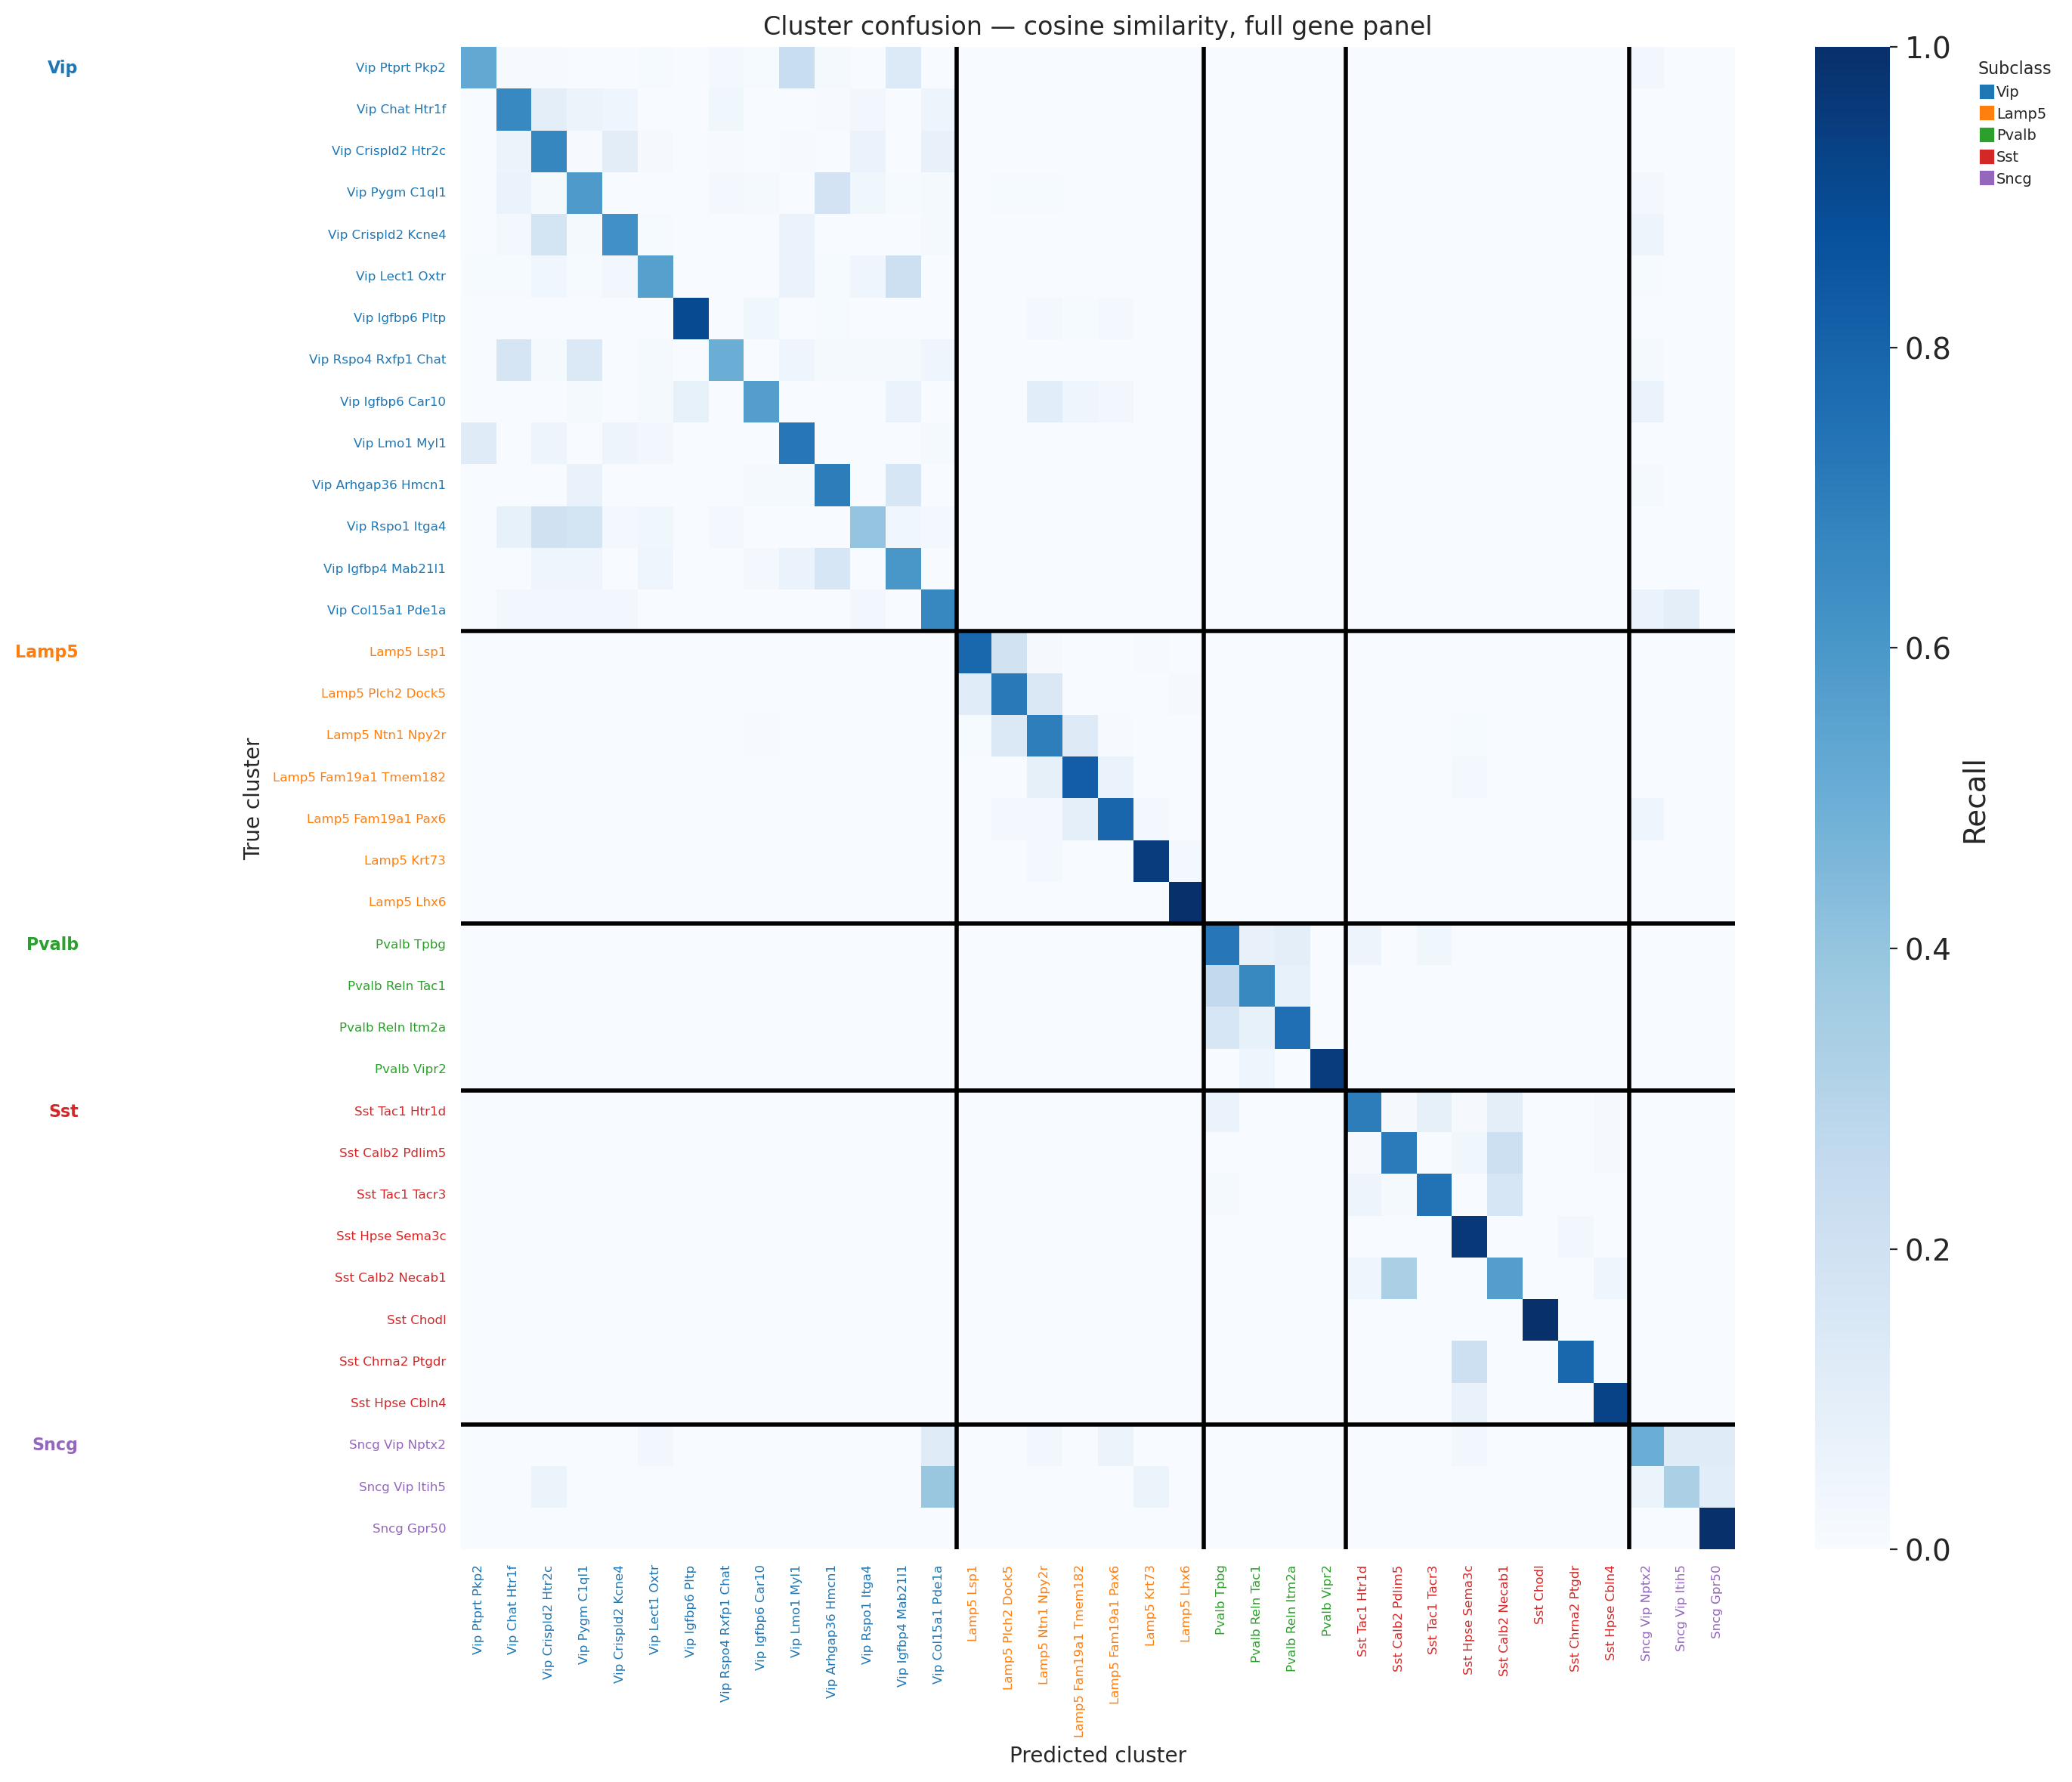

In [79]:
## Cluster-level confusion heatmap (sorted by subclass → cluster)

# ── Build confusion matrix in cluster_order_ref order ────────────────────────
conf_clust = pd.DataFrame(0, index=cluster_order_ref, columns=cluster_order_ref)
for t, p in zip(true_clusters, pred_clusters):
    conf_clust.loc[t, p] += 1
conf_clust_norm = conf_clust.div(conf_clust.sum(axis=1), axis=0)  # row-normalize → recall

# ── Subclass boundary positions ───────────────────────────────────────────────
boundaries = []
prev_subclass = None
for i, cluster in enumerate(cluster_order_ref):
    s = cluster_to_subclass_ref[cluster]
    if s != prev_subclass and i > 0:
        boundaries.append(i)
    prev_subclass = s

# ── Per-subclass color for tick labels ───────────────────────────────────────
subclass_colors = dict(zip(
    subclass_order_ref,
    sns.color_palette('tab10', len(subclass_order_ref)),
))

# ── Heatmap ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    conf_clust_norm,
    cmap='Blues', vmin=0, vmax=1, linewidths=0,
    ax=ax, cbar_kws={'label': 'Recall'},
    xticklabels=True, yticklabels=True,
)

# Thick dividers between subclasses
for b in boundaries:
    ax.axhline(b, color='black', linewidth=2)
    ax.axvline(b, color='black', linewidth=2)

# Color tick labels by subclass
for tick in ax.get_yticklabels():
    s = cluster_to_subclass_ref[tick.get_text()]
    tick.set_color(subclass_colors[s])
    tick.set_fontsize(6)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

for tick in ax.get_xticklabels():
    s = cluster_to_subclass_ref[tick.get_text()]
    tick.set_color(subclass_colors[s])
    tick.set_fontsize(6)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

# Subclass name annotations in left margin at each group boundary
prev_subclass = None
for i, cluster in enumerate(cluster_order_ref):
    s = cluster_to_subclass_ref[cluster]
    if s != prev_subclass:
        ax.text(
            -0.3, i + 0.5, s,
            ha='right', va='center', fontsize=8, fontweight='bold',
            color=subclass_colors[s], transform=ax.get_yaxis_transform(),
        )
        prev_subclass = s

# Legend patches for subclasses
legend_handles = [
    plt.Line2D([0], [0], marker='s', color='w',
               markerfacecolor=subclass_colors[s], markersize=8, label=s)
    for s in subclass_order_ref
]
ax.legend(handles=legend_handles, bbox_to_anchor=(1.18, 1), loc='upper left',
          title='Subclass', fontsize=7, title_fontsize=8, frameon=False)

ax.set_xlabel('Predicted cluster', fontsize=10)
ax.set_ylabel('True cluster', fontsize=10)
ax.set_title('Cluster confusion — cosine similarity, full gene panel', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Chat, Tac1, Crh, Gad2, Penk, Pdyn, Calb2, Lamp5, Cck, Sst, Pvalb , Vip , Reln , Tac2 , Calb1 , Mme , Ndnf , Hpse , Pthlh , Npy

# # Genes to potentially add
# Sncg
# Vipr2/unc5b

Panel: 20 genes — Sst, Pvalb, Vip, Lamp5, Sncg, Cck, Chat, Tac1, Crh, Penk, Pdyn, Calb2, Reln, Tac2, Calb1, Mme, Ndnf, Hpse, Pthlh, Npy

Cluster-level accuracy:  0.554  (1752 / 3162)
Subclass-level accuracy: 0.942  (2980 / 3162)

Cluster                             Subclass         N     Acc
─────────────────────────────────────────────────────────────────
Vip Ptprt Pkp2                      Vip            179   0.430
Vip Chat Htr1f                      Vip            168   0.583
Vip Crispld2 Htr2c                  Vip            160   0.444
Vip Pygm C1ql1                      Vip            124   0.452
Vip Crispld2 Kcne4                  Vip            110   0.364
Vip Lect1 Oxtr                      Vip            108   0.583
Vip Igfbp6 Pltp                     Vip            102   0.608
Vip Rspo4 Rxfp1 Chat                Vip             64   0.609
Vip Igfbp6 Car10                    Vip             63   0.524
Vip Lmo1 Myl1                       Vip             58   0.690
Vip Arhgap3

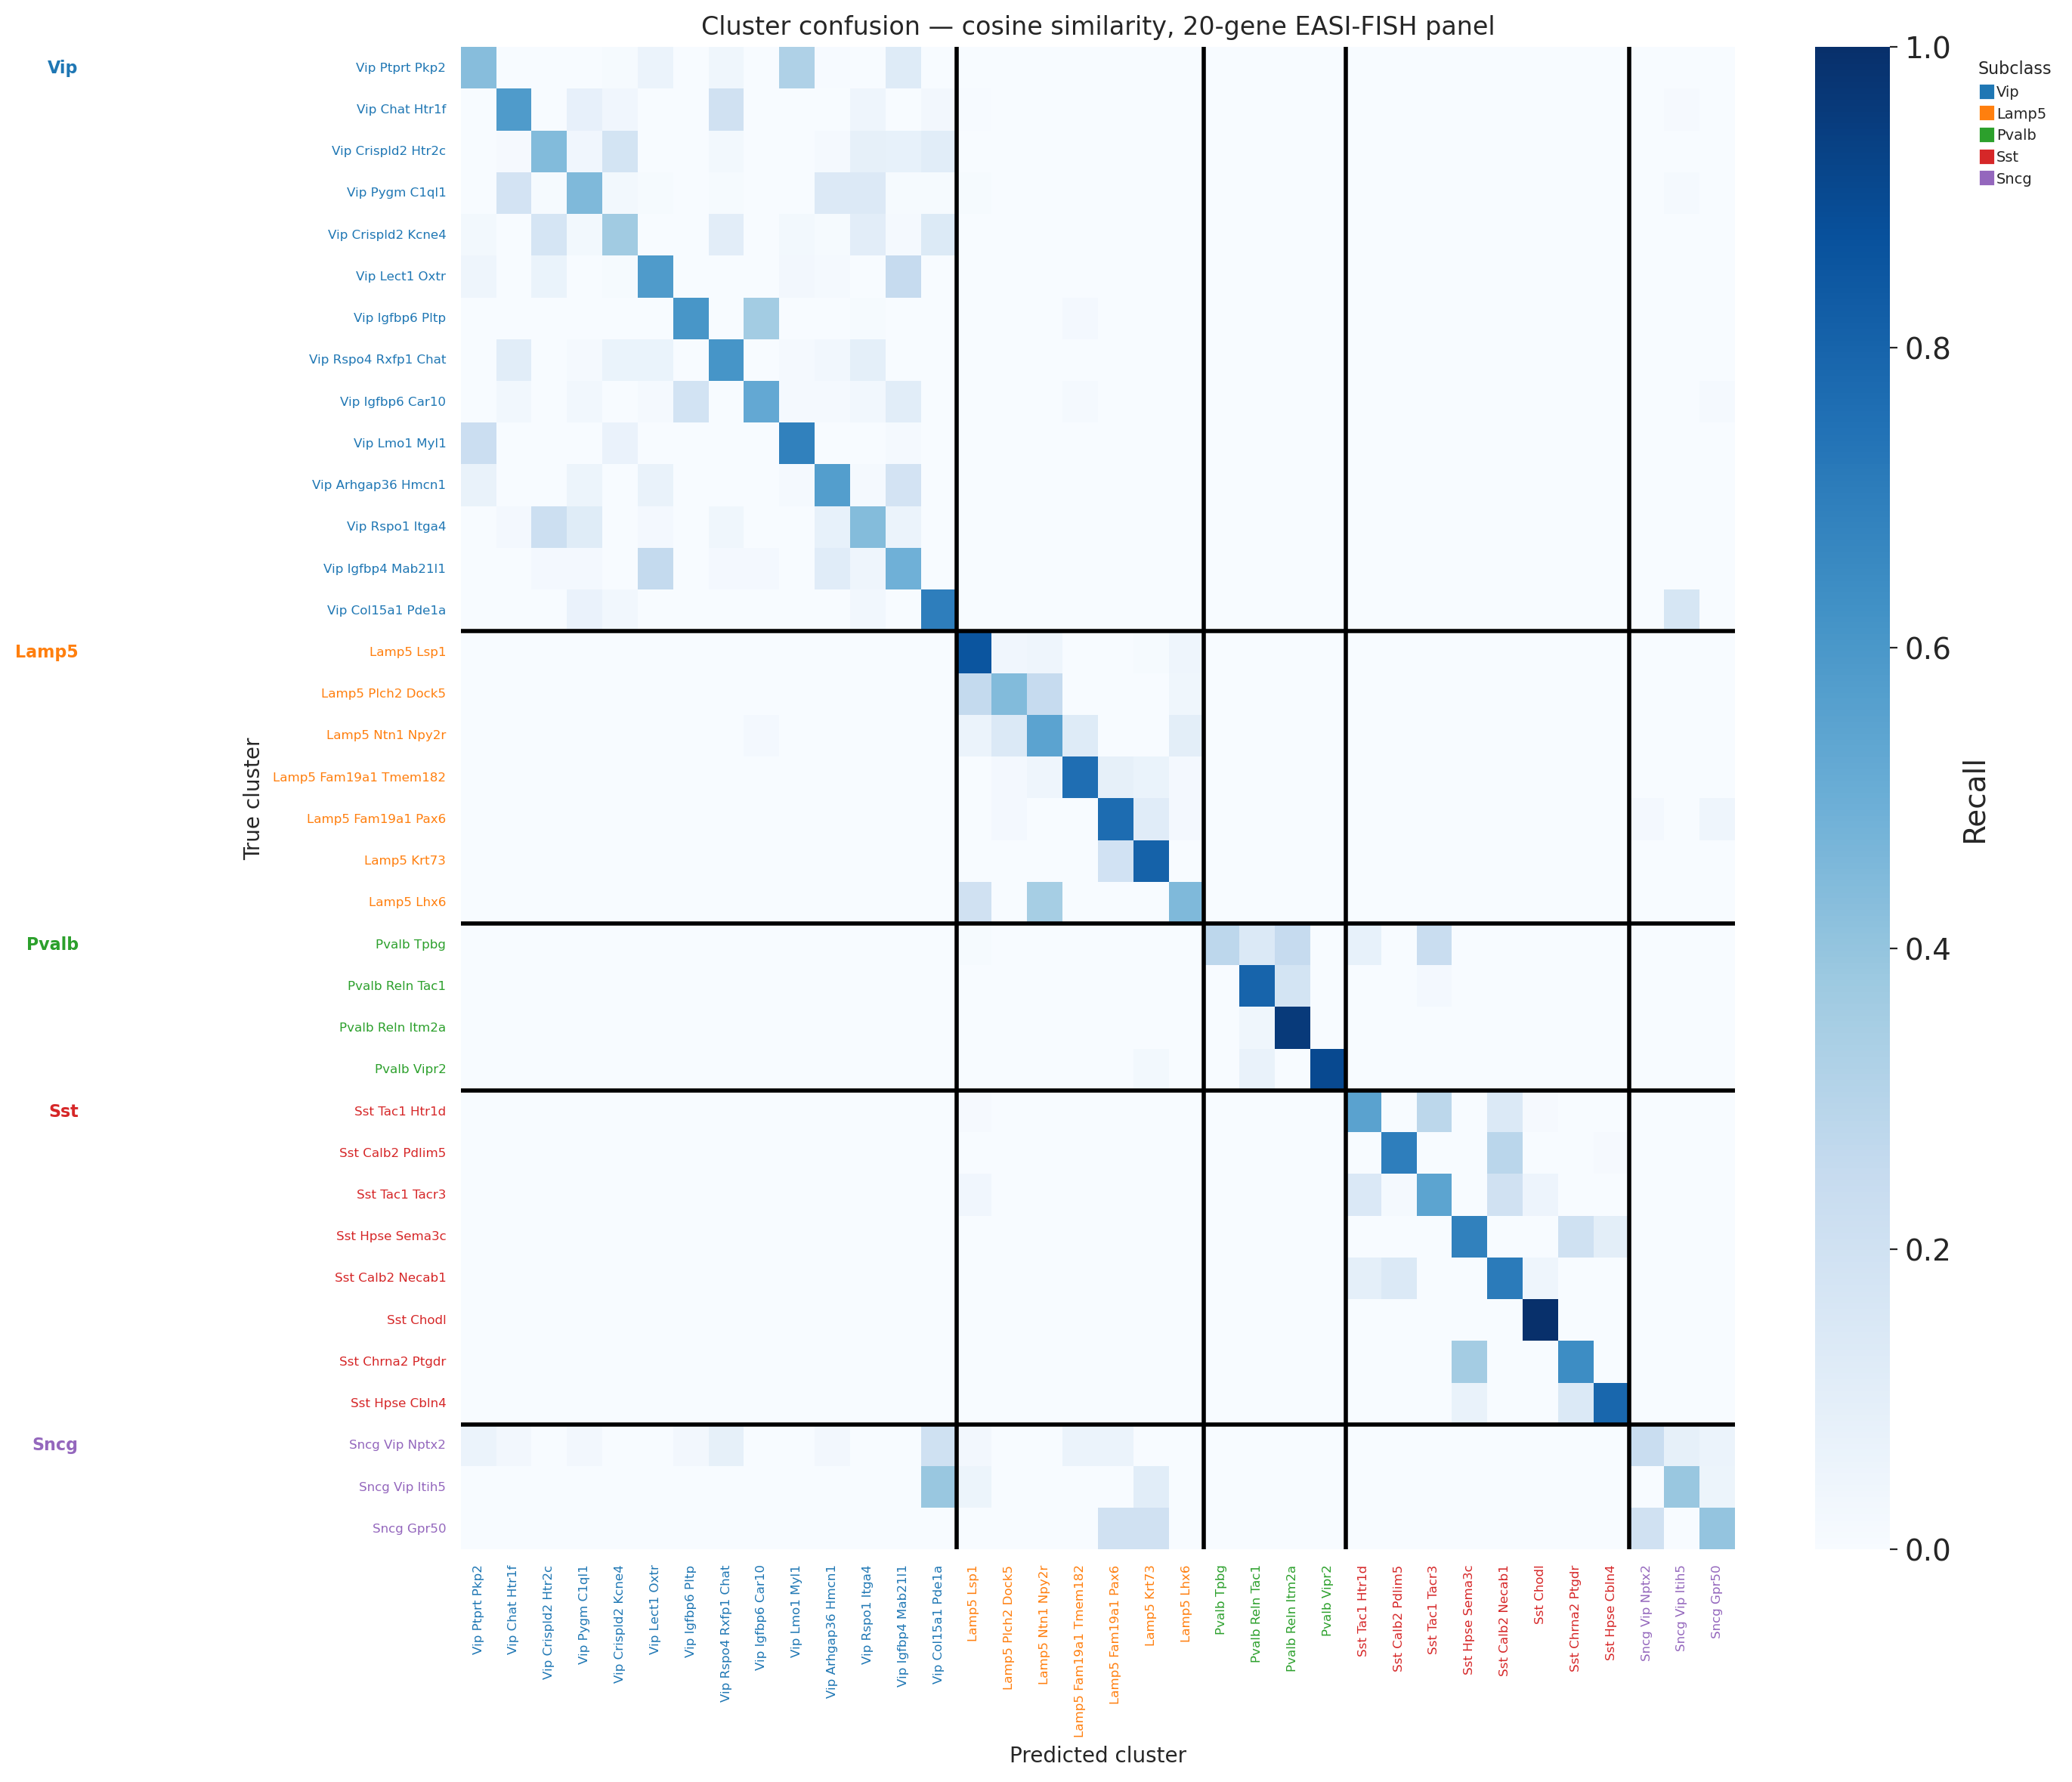

In [108]:
## EASI-FISH gene panel — cosine similarity + cluster confusion matrix

PANEL_GENES = [
    'Sst', 'Pvalb', 'Vip', 'Lamp5','Sncg', 'Cck', 'Chat', 'Tac1', 'Crh', 'Penk',
    'Pdyn', 'Calb2', 'Reln', 'Tac2', 'Calb1', 'Mme', 'Ndnf', 'Hpse', 'Pthlh', 'Npy',
]

# ── Map gene symbols → Entrez ID strings (var_names) ─────────────────────────
symbol_to_id = pd.Series(
    adata_l23_inh.var_names,
    index=adata_l23_inh.var['gene_symbol'],
)
missing      = [g for g in PANEL_GENES if g not in symbol_to_id.index]
panel_ids    = [symbol_to_id[g] for g in PANEL_GENES if g not in missing]
panel_labels = [g for g in PANEL_GENES if g not in missing]
if missing:
    print(f"WARNING — not found in dataset: {missing}")
print(f"Panel: {len(panel_ids)} genes — {', '.join(panel_labels)}\n")

# ── Subset expression matrix and centroids to panel genes ─────────────────────
# X (dense, all cells × all genes) is defined in the centroid cell
panel_col_idx = [adata_l23_inh.var_names.get_loc(gid) for gid in panel_ids]
X_panel   = X[valid_cell_mask][:, panel_col_idx]   # (n_cells × n_panel)
ref_panel = ref_medians[panel_ids]                  # (n_clusters × n_panel)

# ── Cosine similarity ─────────────────────────────────────────────────────────
sim_panel        = cosine_similarity(X_panel, ref_panel.values)
pred_idx_panel   = sim_panel.argmax(axis=1)
pred_clust_panel = np.array([cluster_order_ref[i] for i in pred_idx_panel])
pred_subcl_panel = np.array([cluster_to_subclass_ref[c] for c in pred_clust_panel])

cluster_acc  = (pred_clust_panel == true_clusters).mean()
subclass_acc = (pred_subcl_panel == true_subclass ).mean()
print(f"Cluster-level accuracy:  {cluster_acc:.3f}  ({(pred_clust_panel == true_clusters).sum()} / {len(true_clusters)})")
print(f"Subclass-level accuracy: {subclass_acc:.3f}  ({(pred_subcl_panel == true_subclass ).sum()} / {len(true_subclass)})")

print(f"\n{'Cluster':<35} {'Subclass':<12} {'N':>5}  {'Acc':>6}")
print("─" * 65)
for cluster in cluster_order_ref:
    mask = true_clusters == cluster
    acc  = (pred_clust_panel[mask] == true_clusters[mask]).mean()
    print(f"{cluster:<35} {cluster_to_subclass_ref[cluster]:<12} {mask.sum():>5}  {acc:>6.3f}")

# ── Cluster confusion heatmap ─────────────────────────────────────────────────
conf = pd.DataFrame(0, index=cluster_order_ref, columns=cluster_order_ref)
for t, p in zip(true_clusters, pred_clust_panel):
    conf.loc[t, p] += 1
conf_norm = conf.div(conf.sum(axis=1), axis=0)

boundaries, prev = [], None
for i, c in enumerate(cluster_order_ref):
    s = cluster_to_subclass_ref[c]
    if s != prev and i > 0:
        boundaries.append(i)
    prev = s

subclass_colors = dict(zip(
    subclass_order_ref,
    sns.color_palette('tab10', len(subclass_order_ref)),
))

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    conf_norm, cmap='Blues', vmin=0, vmax=1, linewidths=0,
    ax=ax, cbar_kws={'label': 'Recall'},
    xticklabels=True, yticklabels=True,
)
for b in boundaries:
    ax.axhline(b, color='black', linewidth=2)
    ax.axvline(b, color='black', linewidth=2)

for tick in ax.get_yticklabels():
    tick.set_color(subclass_colors[cluster_to_subclass_ref[tick.get_text()]])
    tick.set_fontsize(6)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

for tick in ax.get_xticklabels():
    tick.set_color(subclass_colors[cluster_to_subclass_ref[tick.get_text()]])
    tick.set_fontsize(6)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

prev = None
for i, c in enumerate(cluster_order_ref):
    s = cluster_to_subclass_ref[c]
    if s != prev:
        ax.text(-0.3, i + 0.5, s, ha='right', va='center', fontsize=8,
                fontweight='bold', color=subclass_colors[s],
                transform=ax.get_yaxis_transform())
        prev = s

legend_handles = [
    plt.Line2D([0], [0], marker='s', color='w',
               markerfacecolor=subclass_colors[s], markersize=8, label=s)
    for s in subclass_order_ref
]
ax.legend(handles=legend_handles, bbox_to_anchor=(1.18, 1), loc='upper left',
          title='Subclass', fontsize=7, title_fontsize=8, frameon=False)

ax.set_xlabel('Predicted cluster', fontsize=10)
ax.set_ylabel('True cluster', fontsize=10)
ax.set_title(f'Cluster confusion — cosine similarity, {len(panel_ids)}-gene EASI-FISH panel', fontsize=12)
plt.tight_layout()
plt.show()

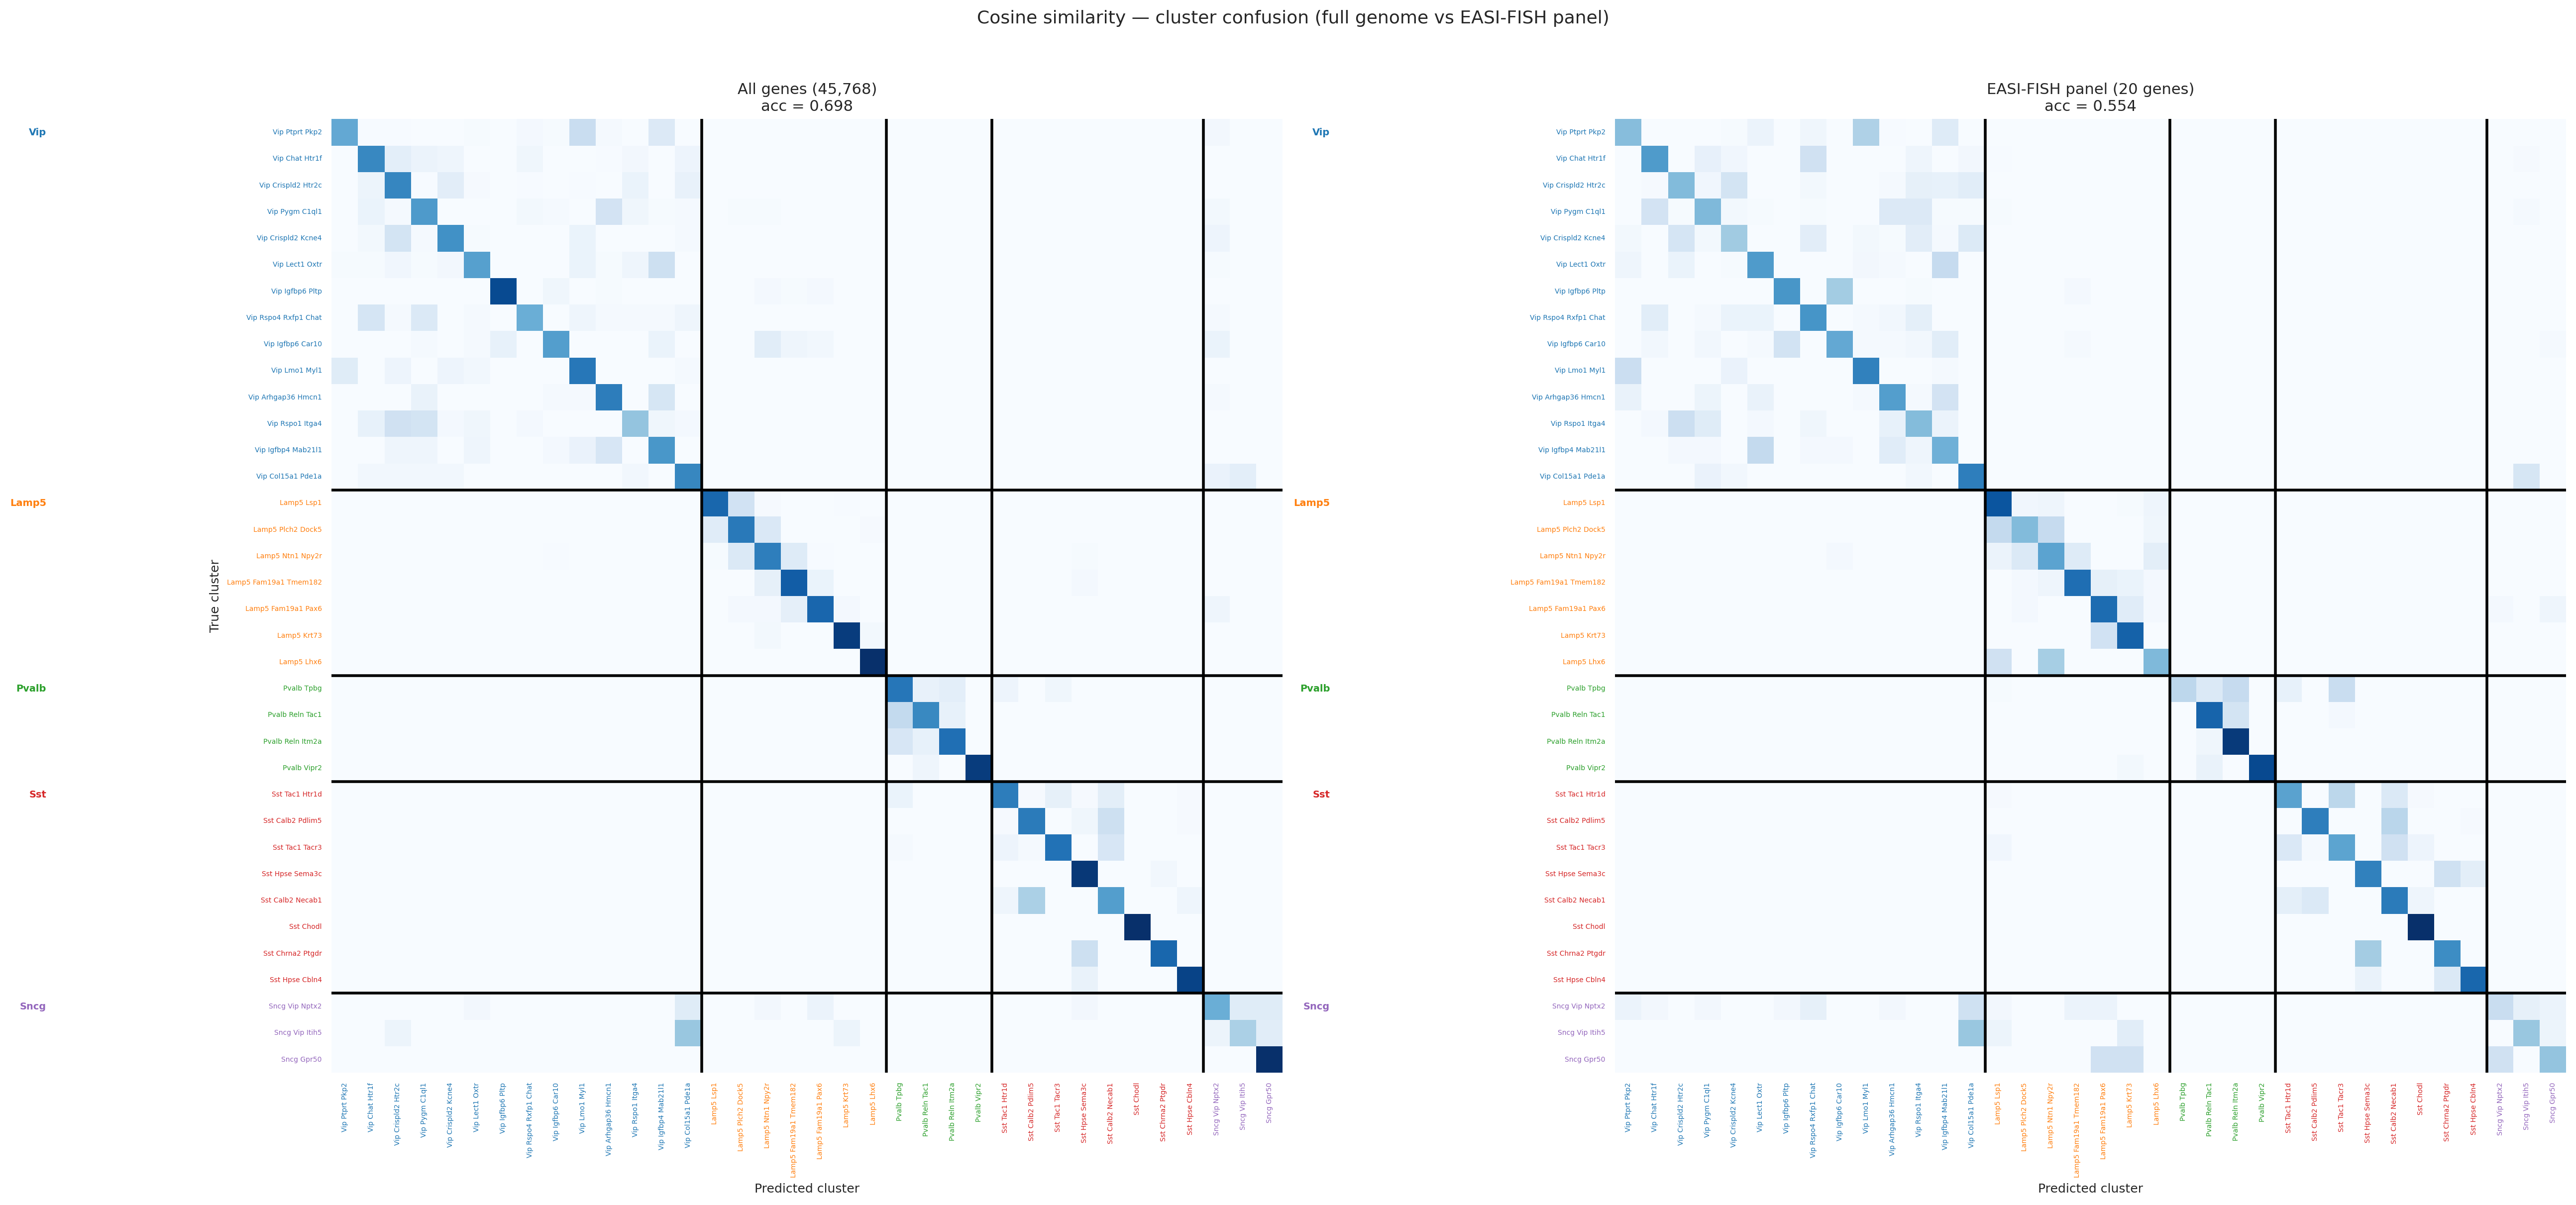

In [109]:
## Side-by-side: full genome vs 20-gene EASI-FISH panel confusion matrices

# ── Recompute both matrices with unambiguous names ────────────────────────────
conf_full = pd.DataFrame(0, index=cluster_order_ref, columns=cluster_order_ref)
for t, p in zip(true_clusters, pred_clusters):
    conf_full.loc[t, p] += 1
conf_full_norm = conf_full.div(conf_full.sum(axis=1), axis=0)

conf_panel = pd.DataFrame(0, index=cluster_order_ref, columns=cluster_order_ref)
for t, p in zip(true_clusters, pred_clust_panel):
    conf_panel.loc[t, p] += 1
conf_panel_norm = conf_panel.div(conf_panel.sum(axis=1), axis=0)

full_acc  = (pred_clusters    == true_clusters).mean()
panel_acc = (pred_clust_panel == true_clusters).mean()

# ── Shared drawing helper ─────────────────────────────────────────────────────
def draw_conf_heatmap(ax, conf_norm, title, show_ylabel=True, show_cbar=True):
    sns.heatmap(
        conf_norm, cmap='Blues', vmin=0, vmax=1, linewidths=0,
        ax=ax, cbar=show_cbar,
        cbar_kws={'label': 'Recall', 'shrink': 0.6} if show_cbar else {},
        xticklabels=True, yticklabels=True,
    )
    for b in boundaries:
        ax.axhline(b, color='black', linewidth=2)
        ax.axvline(b, color='black', linewidth=2)

    for tick in ax.get_yticklabels():
        tick.set_color(subclass_colors[cluster_to_subclass_ref[tick.get_text()]])
        tick.set_fontsize(5)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

    for tick in ax.get_xticklabels():
        tick.set_color(subclass_colors[cluster_to_subclass_ref[tick.get_text()]])
        tick.set_fontsize(5)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

    prev = None
    for i, c in enumerate(cluster_order_ref):
        s = cluster_to_subclass_ref[c]
        if s != prev:
            ax.text(-0.3, i + 0.5, s, ha='right', va='center', fontsize=7,
                    fontweight='bold', color=subclass_colors[s],
                    transform=ax.get_yaxis_transform())
            prev = s

    ax.set_xlabel('Predicted cluster', fontsize=9)
    ax.set_ylabel('True cluster' if show_ylabel else '', fontsize=9)
    ax.set_title(title, fontsize=11)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, (ax_full, ax_panel) = plt.subplots(1, 2, figsize=(26, 12))

draw_conf_heatmap(
    ax_full,  conf_full_norm,
    f'All genes ({X_query.shape[1]:,})\nacc = {full_acc:.3f}',
    show_ylabel=True, show_cbar=False,
)
draw_conf_heatmap(
    ax_panel, conf_panel_norm,
    f'EASI-FISH panel ({len(panel_ids)} genes)\nacc = {panel_acc:.3f}',
    show_ylabel=False, show_cbar=False,
)

# legend_handles = [
#     plt.Line2D([0], [0], marker='s', color='w',
#                markerfacecolor=subclass_colors[s], markersize=8, label=s)
#     for s in subclass_order_ref
# ]
# ax_panel.legend(handles=legend_handles, bbox_to_anchor=(1.18, 1), loc='upper left',
#                 title='Subclass', fontsize=7, title_fontsize=8, frameon=False)

plt.suptitle('Cosine similarity — cluster confusion (full genome vs EASI-FISH panel)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Now exploring effect of discretization

In [95]:
from sklearn.mixture import GaussianMixture
from scipy.optimize import brentq

PANEL_GENES = [
    'Sst', 'Pvalb', 'Vip', 'Lamp5','Sncg', 'Cck', 'Chat', 'Tac1', 'Crh', 'Penk',
    'Pdyn', 'Calb2', 'Reln', 'Tac2', 'Calb1', 'Mme', 'Ndnf', 'Hpse', 'Pthlh', 'Npy',
]

THRESHOLD_PROBS = [0.50, 0.75, 0.95]
THRESHOLD_COLORS = {0.50: 'gold', 0.75: 'darkorange', 0.95: 'red'}

gmm_thresholds   = {}   # p = 0.50
gmm_thresholds75 = {}   # p = 0.75
gmm_thresholds95 = {}   # p = 0.95
gmm_models       = {}

for this_gene in PANEL_GENES:
    gene_idx   = adata_l23_inh.var['gene_symbol'] == this_gene
    log_counts = np.log1p(adata_l23_inh.layers['counts'][:, gene_idx].ravel())

    gmm = GaussianMixture(n_components=2, random_state=42)
    gmm.fit(log_counts.reshape(-1, 1))

    order   = np.argsort(gmm.means_.ravel())
    lo_mean = float(gmm.means_.ravel()[order[0]])
    hi_mean = float(gmm.means_.ravel()[order[1]])
    hi_idx  = int(order[1])

    # Bracket spanning the full data range — valid for all probability levels
    x_lo = 0.0
    x_hi = float(log_counts.max()) + 2.0

    def _find_threshold(prob, _gmm=gmm, _hi=hi_idx, _x_lo=x_lo, _x_hi=x_hi):
        def score(x):
            return _gmm.predict_proba([[x]])[0][_hi] - prob
        try:
            return brentq(score, _x_lo, _x_hi)
        except ValueError:
            return np.nan

    t50 = _find_threshold(0.50)
    t75 = _find_threshold(0.75)
    t95 = _find_threshold(0.95)

    gmm_thresholds[this_gene]   = t50
    gmm_thresholds75[this_gene] = t75
    gmm_thresholds95[this_gene] = t95
    gmm_models[this_gene]       = gmm

    print(f"{this_gene:10s}  lo={lo_mean:.2f}  hi={hi_mean:.2f}  "
          f"p50={t50:.2f}  p75={t75:.2f}  p95={t95:.2f}")

Sst         lo=0.41  hi=8.60  p50=2.74  p75=2.88  p95=3.10
Pvalb       lo=0.00  hi=5.58  p50=0.00  p75=0.00  p95=0.01
Vip         lo=0.98  hi=10.56  p50=6.70  p75=6.79  p95=6.96
Lamp5       lo=0.17  hi=7.68  p50=2.02  p75=2.08  p95=2.18
Sncg        lo=0.00  hi=4.60  p50=0.01  p75=0.01  p95=0.01
Cck         lo=0.28  hi=6.51  p50=1.68  p75=1.80  p95=1.98
Chat        lo=0.00  hi=4.66  p50=0.01  p75=0.01  p95=0.01
Tac1        lo=0.00  hi=5.37  p50=0.00  p75=0.00  p95=0.01
Crh         lo=0.20  hi=8.12  p50=1.90  p75=1.98  p95=2.11
Penk        lo=0.19  hi=7.50  p50=1.52  p75=1.61  p95=1.76
Pdyn        lo=0.00  hi=4.14  p50=0.00  p75=0.00  p95=0.01
Calb2       lo=0.07  hi=7.01  p50=0.91  p75=0.97  p95=1.05
Reln        lo=0.00  hi=5.58  p50=0.00  p75=0.00  p95=0.01
Tac2        lo=0.20  hi=8.27  p50=1.91  p75=1.99  p95=2.12
Calb1       lo=0.13  hi=7.28  p50=1.25  p75=1.33  p95=1.45
Mme         lo=0.00  hi=4.07  p50=0.01  p75=0.01  p95=0.01
Ndnf        lo=0.00  hi=5.75  p50=0.00  p75=0.01  p95=0

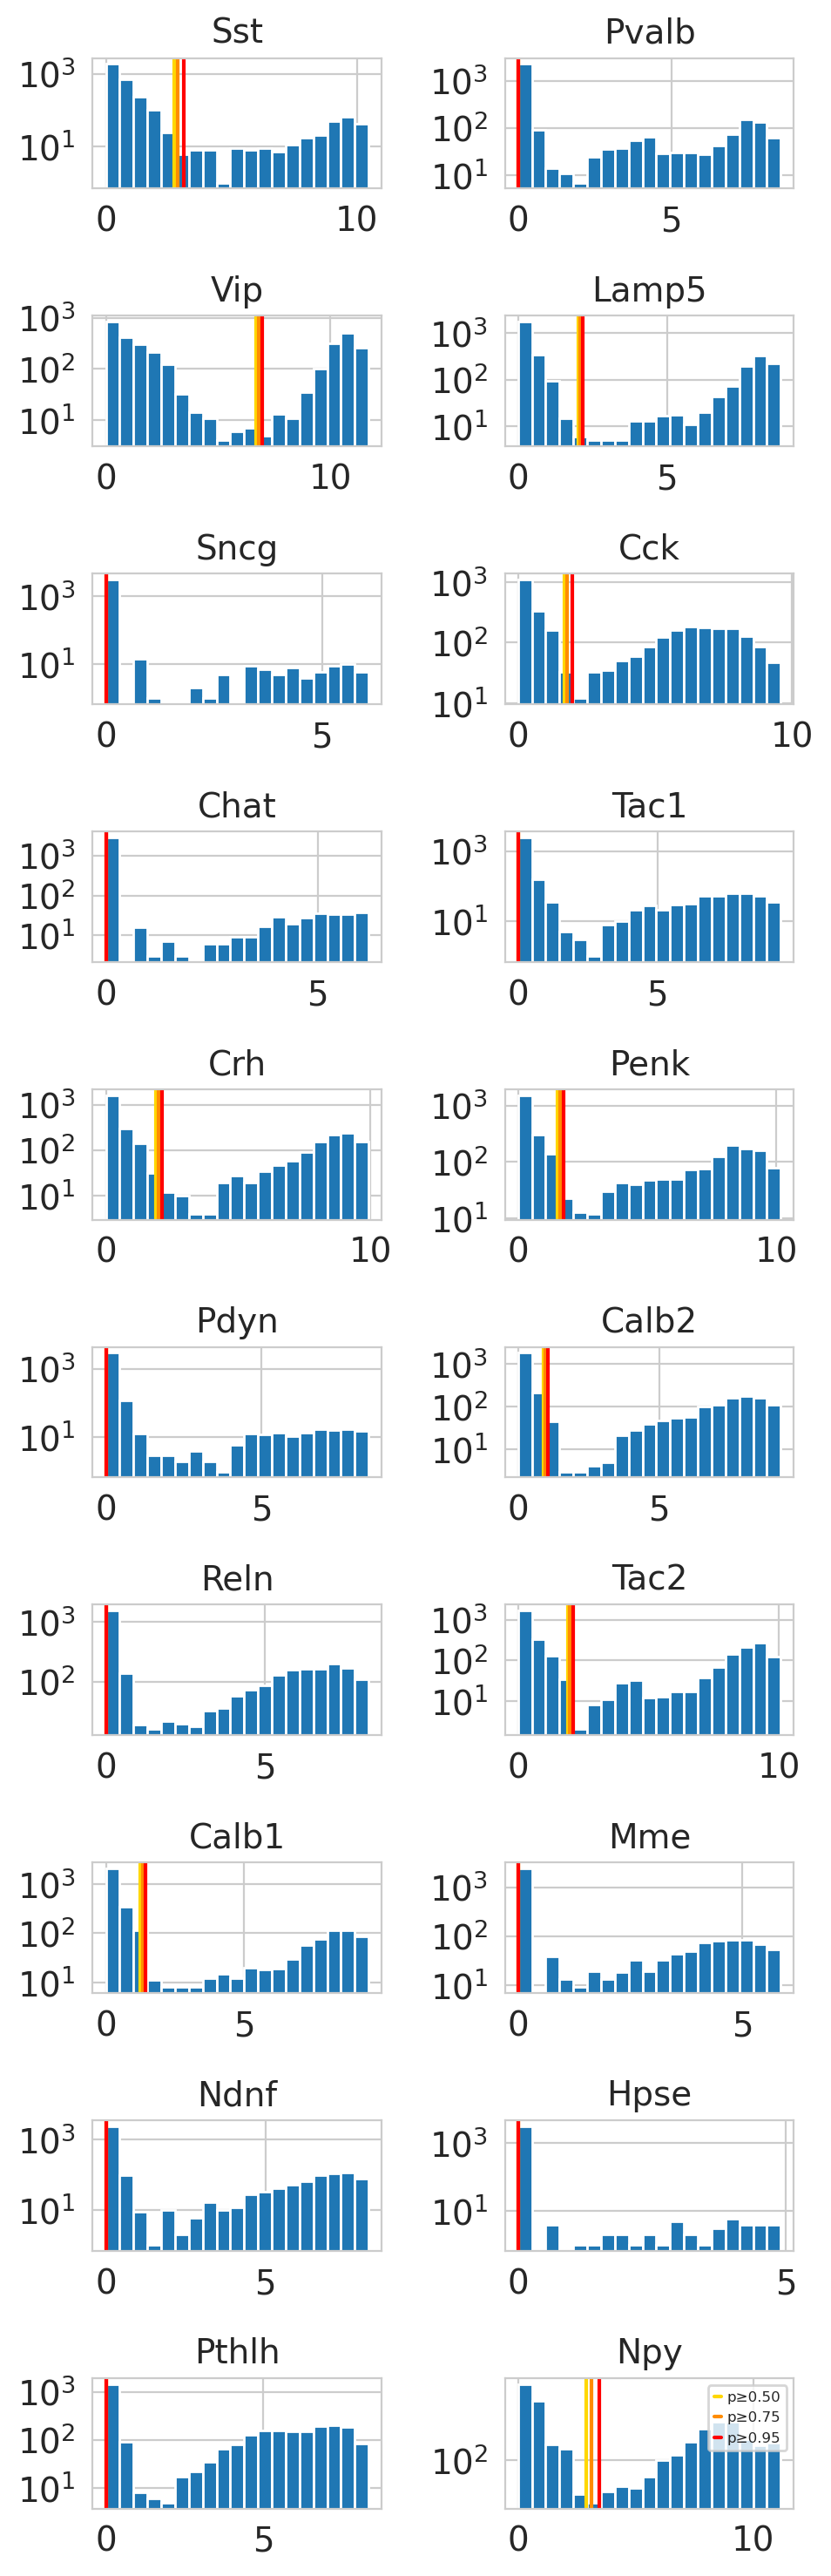

In [96]:
fig, ax = plt.subplots(int(len(PANEL_GENES) / 2), 2, figsize=(5, 15))
for i_ax, this_gene in enumerate(PANEL_GENES):
    log_gene_counts = np.log1p(
        adata_l23_inh.layers['counts'][:, adata_l23_inh.var['gene_symbol'] == this_gene]
    )
    ax.ravel()[i_ax].hist(
        log_gene_counts,
        bins=np.linspace(np.nanquantile(log_gene_counts, .01), np.nanquantile(log_gene_counts, .99), 20),
    )
    ax.ravel()[i_ax].set_title(this_gene)
    ax.ravel()[i_ax].set_yscale('log')

    for thresh_dict, prob in zip(
        [gmm_thresholds, gmm_thresholds75, gmm_thresholds95],
        THRESHOLD_PROBS,
    ):
        t = thresh_dict.get(this_gene, np.nan)
        if not np.isnan(t):
            ax.ravel()[i_ax].axvline(
                t, color=THRESHOLD_COLORS[prob], linewidth=1.5,
                label=f'p≥{prob:.2f}',
            )

# Single shared legend on the last subplot
ax.ravel()[-1].legend(fontsize=6, loc='upper right')
fig.tight_layout()

In [102]:
from sklearn.metrics.pairwise import cosine_similarity as cos_sim


def binarize_expression(log_X, gene_list, thresholds):
    """
    Threshold log-count columns into binary 0/1 using per-gene GMM thresholds.

    Parameters
    ----------
    log_X : ndarray (n_cells, n_genes)
    gene_list : list[str] — symbol for each column
    thresholds : dict — gene_symbol → log1p threshold

    Returns
    -------
    binary : ndarray (n_cells, n_genes), float32
    """
    binary = np.zeros(log_X.shape, dtype=np.float32)
    for j, gene in enumerate(gene_list):
        t = thresholds.get(gene, np.nan)
        if not np.isnan(t):
            binary[:, j] = (log_X[:, j] > t).astype(np.float32)
    return binary


def classify_two_step(
    adata,
    ref_medians,
    cluster_order,
    cluster_to_subclass,
    panel_ids,
    symbol_to_id,
    thresholds,
    cardinal_genes=None,
    binarize_panel=False,
):
    """
    Two-step cell-type classification matching the EASI-FISH setting.

    Step 1 — Cardinal class assignment:
        Binarize expression of cardinal subclass markers (Sst, Pvalb, Vip,
        Lamp5, Sncg). Assign each cell to the class whose marker exceeds the
        GMM threshold; tie-break by raw log-count magnitude. Cells with no
        expressed cardinal marker are labelled 'Unknown'.

        Override: Sncg+ expression takes priority over Vip+, because a large
        fraction of Sncg cells co-express Vip at high levels.

    Step 2 — Within-class cluster assignment:
        Restrict cosine similarity to cluster centroids whose subclass matches
        the Step-1 assignment. Assign the nearest centroid.

    Parameters
    ----------
    binarize_panel : bool, default False
        If True, binarize all panel gene expression (query and reference) before
        computing cosine similarity in Step 2, using the same thresholds dict.

    Returns
    -------
    pred_class   : ndarray (n_cells,) — predicted cardinal subclass
    pred_cluster : ndarray (n_cells,) — predicted cluster
    """
    if cardinal_genes is None:
        cardinal_genes = ['Sst', 'Pvalb', 'Vip', 'Lamp5', 'Sncg']

    X_dense = adata.layers['counts']
    if hasattr(X_dense, 'toarray'):
        X_dense = X_dense.toarray()

    # ── Step 1: binarized cardinal-marker assignment ──────────────────────────
    c_ids   = [symbol_to_id[g] for g in cardinal_genes if g in symbol_to_id.index]
    c_genes = [g for g in cardinal_genes if g in symbol_to_id.index]
    c_cols  = [adata.var_names.get_loc(gid) for gid in c_ids]

    log_Xc = np.log1p(X_dense[:, c_cols])
    binary = binarize_expression(log_Xc, c_genes, thresholds)

    pred_class = np.empty(len(adata), dtype=object)
    for i in range(len(adata)):
        b = binary[i]
        if b.sum() == 0:
            pred_class[i] = 'Unknown'
        else:
            cands = np.where(b == b.max())[0]
            best  = cands[np.argmax(log_Xc[i, cands])]   # tie-break by expression
            pred_class[i] = c_genes[best]

    # Sncg co-expresses Vip at high levels; Sncg+ overrides a Vip assignment.
    if 'Sncg' in c_genes and 'Vip' in c_genes:
        sncg_col = c_genes.index('Sncg')
        vip_assigned = pred_class == 'Vip'
        sncg_positive = binary[:, sncg_col] > 0
        pred_class[vip_assigned & sncg_positive] = 'Sncg'

    # ── Step 2: cosine similarity within assigned class ───────────────────────
    p_cols     = [adata.var_names.get_loc(gid) for gid in panel_ids]
    X_panel    = X_dense[:, p_cols]
    ref_panel  = ref_medians[panel_ids].values

    if binarize_panel:
        panel_symbols = [adata.var.loc[gid, 'gene_symbol'] for gid in panel_ids]
        X_panel   = binarize_expression(np.log1p(X_panel),   panel_symbols, thresholds)
        ref_panel = binarize_expression(np.log1p(ref_panel), panel_symbols, thresholds)

    # Pre-index cluster positions grouped by subclass for vectorised lookup
    subclass_idx = {}
    for idx, c in enumerate(cluster_order):
        subclass_idx.setdefault(cluster_to_subclass[c], []).append(idx)

    pred_cluster = np.empty(len(adata), dtype=object)
    for i, cell_class in enumerate(pred_class):
        idxs = subclass_idx.get(cell_class, list(range(len(cluster_order))))
        sim  = cos_sim(X_panel[i:i+1], ref_panel[idxs])[0]
        pred_cluster[i] = cluster_order[idxs[int(sim.argmax())]]

    return pred_class, pred_cluster

Two-step (binarized cardinal p≥0.95 → cosine within class, 20-gene panel)
  Cardinal class accuracy : 0.926  (2929 / 3162)
  Cluster accuracy        : 0.581  (1838 / 3162)

Predicted class breakdown:
Vip        1183
Lamp5       960
Pvalb       556
Sst         244
Unknown     135
Sncg         84


/tmp/ipykernel_697616/3969979381.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


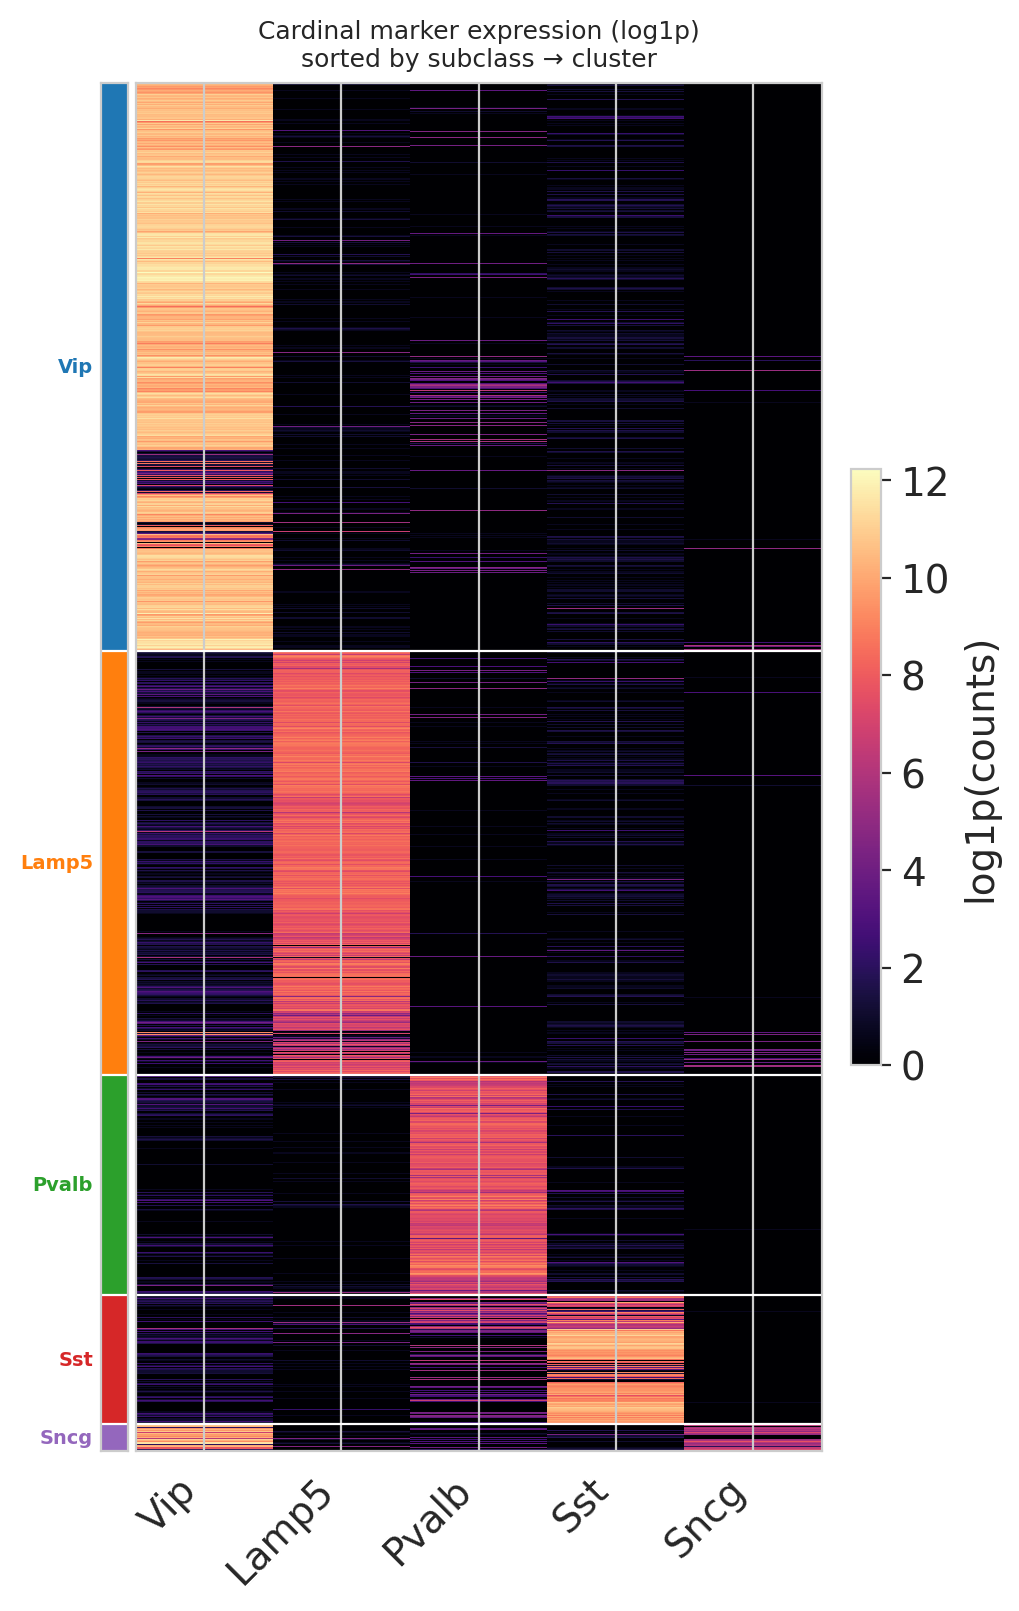

In [98]:
## Two-step classification: binarized cardinal markers → cosine within class

CARDINAL_GENES = ['Vip', 'Lamp5', 'Pvalb','Sst', 'Sncg']

pred_class_2s, pred_cluster_2s = classify_two_step(
    adata_l23_inh,
    ref_medians,
    cluster_order_ref,
    cluster_to_subclass_ref,
    panel_ids,
    symbol_to_id,
    gmm_thresholds95,        # p ≥ 0.95 binarization
    cardinal_genes=CARDINAL_GENES,
)

# ── Evaluate on valid-cluster cells ──────────────────────────────────────────
pred_cl_v  = pred_cluster_2s[valid_cell_mask]
pred_cls_v = pred_class_2s[valid_cell_mask]

class_acc   = (pred_cls_v == true_subclass).mean()
cluster_acc = (pred_cl_v  == true_clusters).mean()

print(f"Two-step (binarized cardinal p≥0.95 → cosine within class, {len(panel_ids)}-gene panel)")
print(f"  Cardinal class accuracy : {class_acc:.3f}  ({(pred_cls_v == true_subclass).sum()} / {len(true_subclass)})")
print(f"  Cluster accuracy        : {cluster_acc:.3f}  ({(pred_cl_v == true_clusters).sum()} / {len(true_clusters)})")
print(f"\nPredicted class breakdown:")
print(pd.Series(pred_cls_v).value_counts().to_string())

# ── Sanity check: cardinal marker expression heatmap ─────────────────────────
c_ids  = [symbol_to_id[g] for g in CARDINAL_GENES if g in symbol_to_id.index]
c_cols = [adata_l23_inh.var_names.get_loc(gid) for gid in c_ids]

# Sort valid cells by subclass_order_ref, then cluster_order_ref within
obs_valid = adata_l23_inh.obs.loc[valid_cell_mask, ['subclass', 'cluster']].copy()
obs_valid['_sc'] = obs_valid['subclass'].map({s: i for i, s in enumerate(subclass_order_ref)})
obs_valid['_cl'] = obs_valid['cluster'].map({c: i for i, c in enumerate(cluster_order_ref)})
obs_sorted_h = obs_valid.sort_values(['_sc', '_cl'])

row_idx  = adata_l23_inh.obs_names.get_indexer(obs_sorted_h.index)
log_Xc   = np.log1p(X[row_idx][:, c_cols])

# Subclass block boundaries and midpoints
bounds, midpoints = [], []
prev, start_i = None, 0
for i, s in enumerate(obs_sorted_h['subclass']):
    if s != prev:
        if prev is not None:
            bounds.append(i - 0.5)
            midpoints.append((prev, (start_i + i - 1) / 2))
        start_i, prev = i, s
midpoints.append((prev, (start_i + len(obs_sorted_h) - 1) / 2))

fig, (ax_bar, ax_hm) = plt.subplots(
    1, 2, figsize=(5, 9),
    gridspec_kw={'width_ratios': [0.18, 5], 'wspace': 0.02},
)

# ── Left color strip ──────────────────────────────────────────────────────────
rgb = np.array([list(subclass_colors[s]) for s in obs_sorted_h['subclass']], dtype=np.float32)
ax_bar.imshow(rgb.reshape(-1, 1, 3), aspect='auto', interpolation='nearest')
ax_bar.set_xticks([]); ax_bar.set_yticks([])
for b in bounds:
    ax_bar.axhline(b, color='white', linewidth=0.8)

for s, mid in midpoints:
    ax_bar.text(-0.3, mid, s, ha='right', va='center', fontsize=7, fontweight='bold',
                color=subclass_colors[s], transform=ax_bar.get_yaxis_transform())

# ── Main heatmap ──────────────────────────────────────────────────────────────
im = ax_hm.imshow(log_Xc, aspect='auto', interpolation='nearest', cmap='magma')
ax_hm.set_xticks(range(len(CARDINAL_GENES)))
ax_hm.set_xticklabels(CARDINAL_GENES, rotation=45, ha='right')
ax_hm.set_yticks([])
for b in bounds:
    ax_hm.axhline(b, color='white', linewidth=0.8)

ax_hm.set_title('Cardinal marker expression (log1p)\nsorted by subclass → cluster', fontsize=9)
plt.colorbar(im, ax=ax_hm, label='log1p(counts)', fraction=0.04, pad=0.04)
plt.tight_layout()
plt.show()

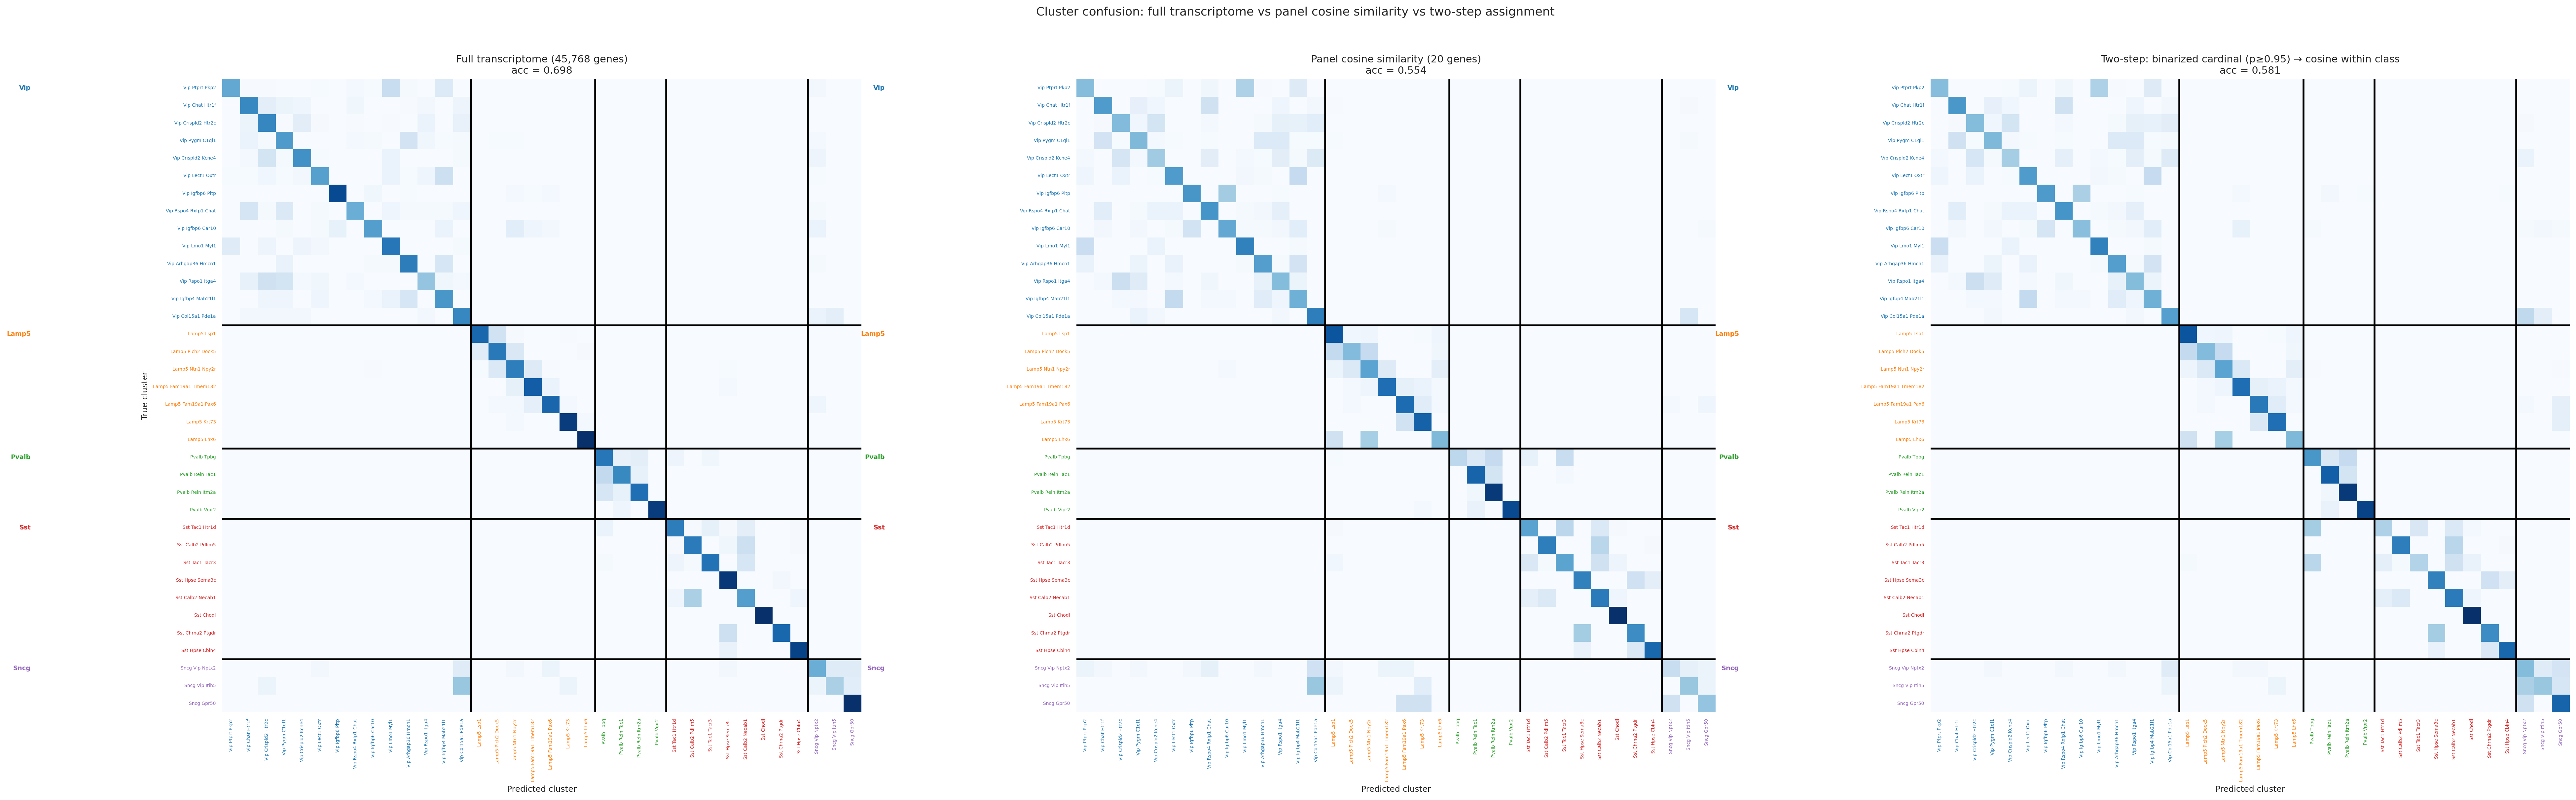

In [100]:
## Three-way comparison: full transcriptome vs panel cosine vs two-step

# ── Build two-step confusion matrix ──────────────────────────────────────────
conf_2step = pd.DataFrame(0, index=cluster_order_ref, columns=cluster_order_ref)
for t, p in zip(true_clusters, pred_cl_v):
    conf_2step.loc[t, p] += 1
conf_2step_norm = conf_2step.div(conf_2step.sum(axis=1), axis=0)

acc_full  = (pred_clusters    == true_clusters).mean()
acc_panel = (pred_clust_panel == true_clusters).mean()
acc_2step = (pred_cl_v        == true_clusters).mean()

# ── Figure ────────────────────────────────────────────────────────────────────
fig, (ax_full, ax_panel, ax_2step) = plt.subplots(1, 3, figsize=(39, 12))

draw_conf_heatmap(
    ax_full, conf_full_norm,
    f'Full transcriptome ({X_query.shape[1]:,} genes)\nacc = {acc_full:.3f}',
    show_ylabel=True, show_cbar=False,
)
draw_conf_heatmap(
    ax_panel, conf_panel_norm,
    f'Panel cosine similarity ({len(panel_ids)} genes)\nacc = {acc_panel:.3f}',
    show_ylabel=False, show_cbar=False,
)
draw_conf_heatmap(
    ax_2step, conf_2step_norm,
    f'Two-step: binarized cardinal (p≥0.95) → cosine within class\nacc = {acc_2step:.3f}',
    show_ylabel=False, show_cbar=False,
)

plt.suptitle(
    'Cluster confusion: full transcriptome vs panel cosine similarity vs two-step assignment',
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.show()

Two-step, continuous panel : acc = 0.581
Two-step, binarized panel  : acc = 0.520


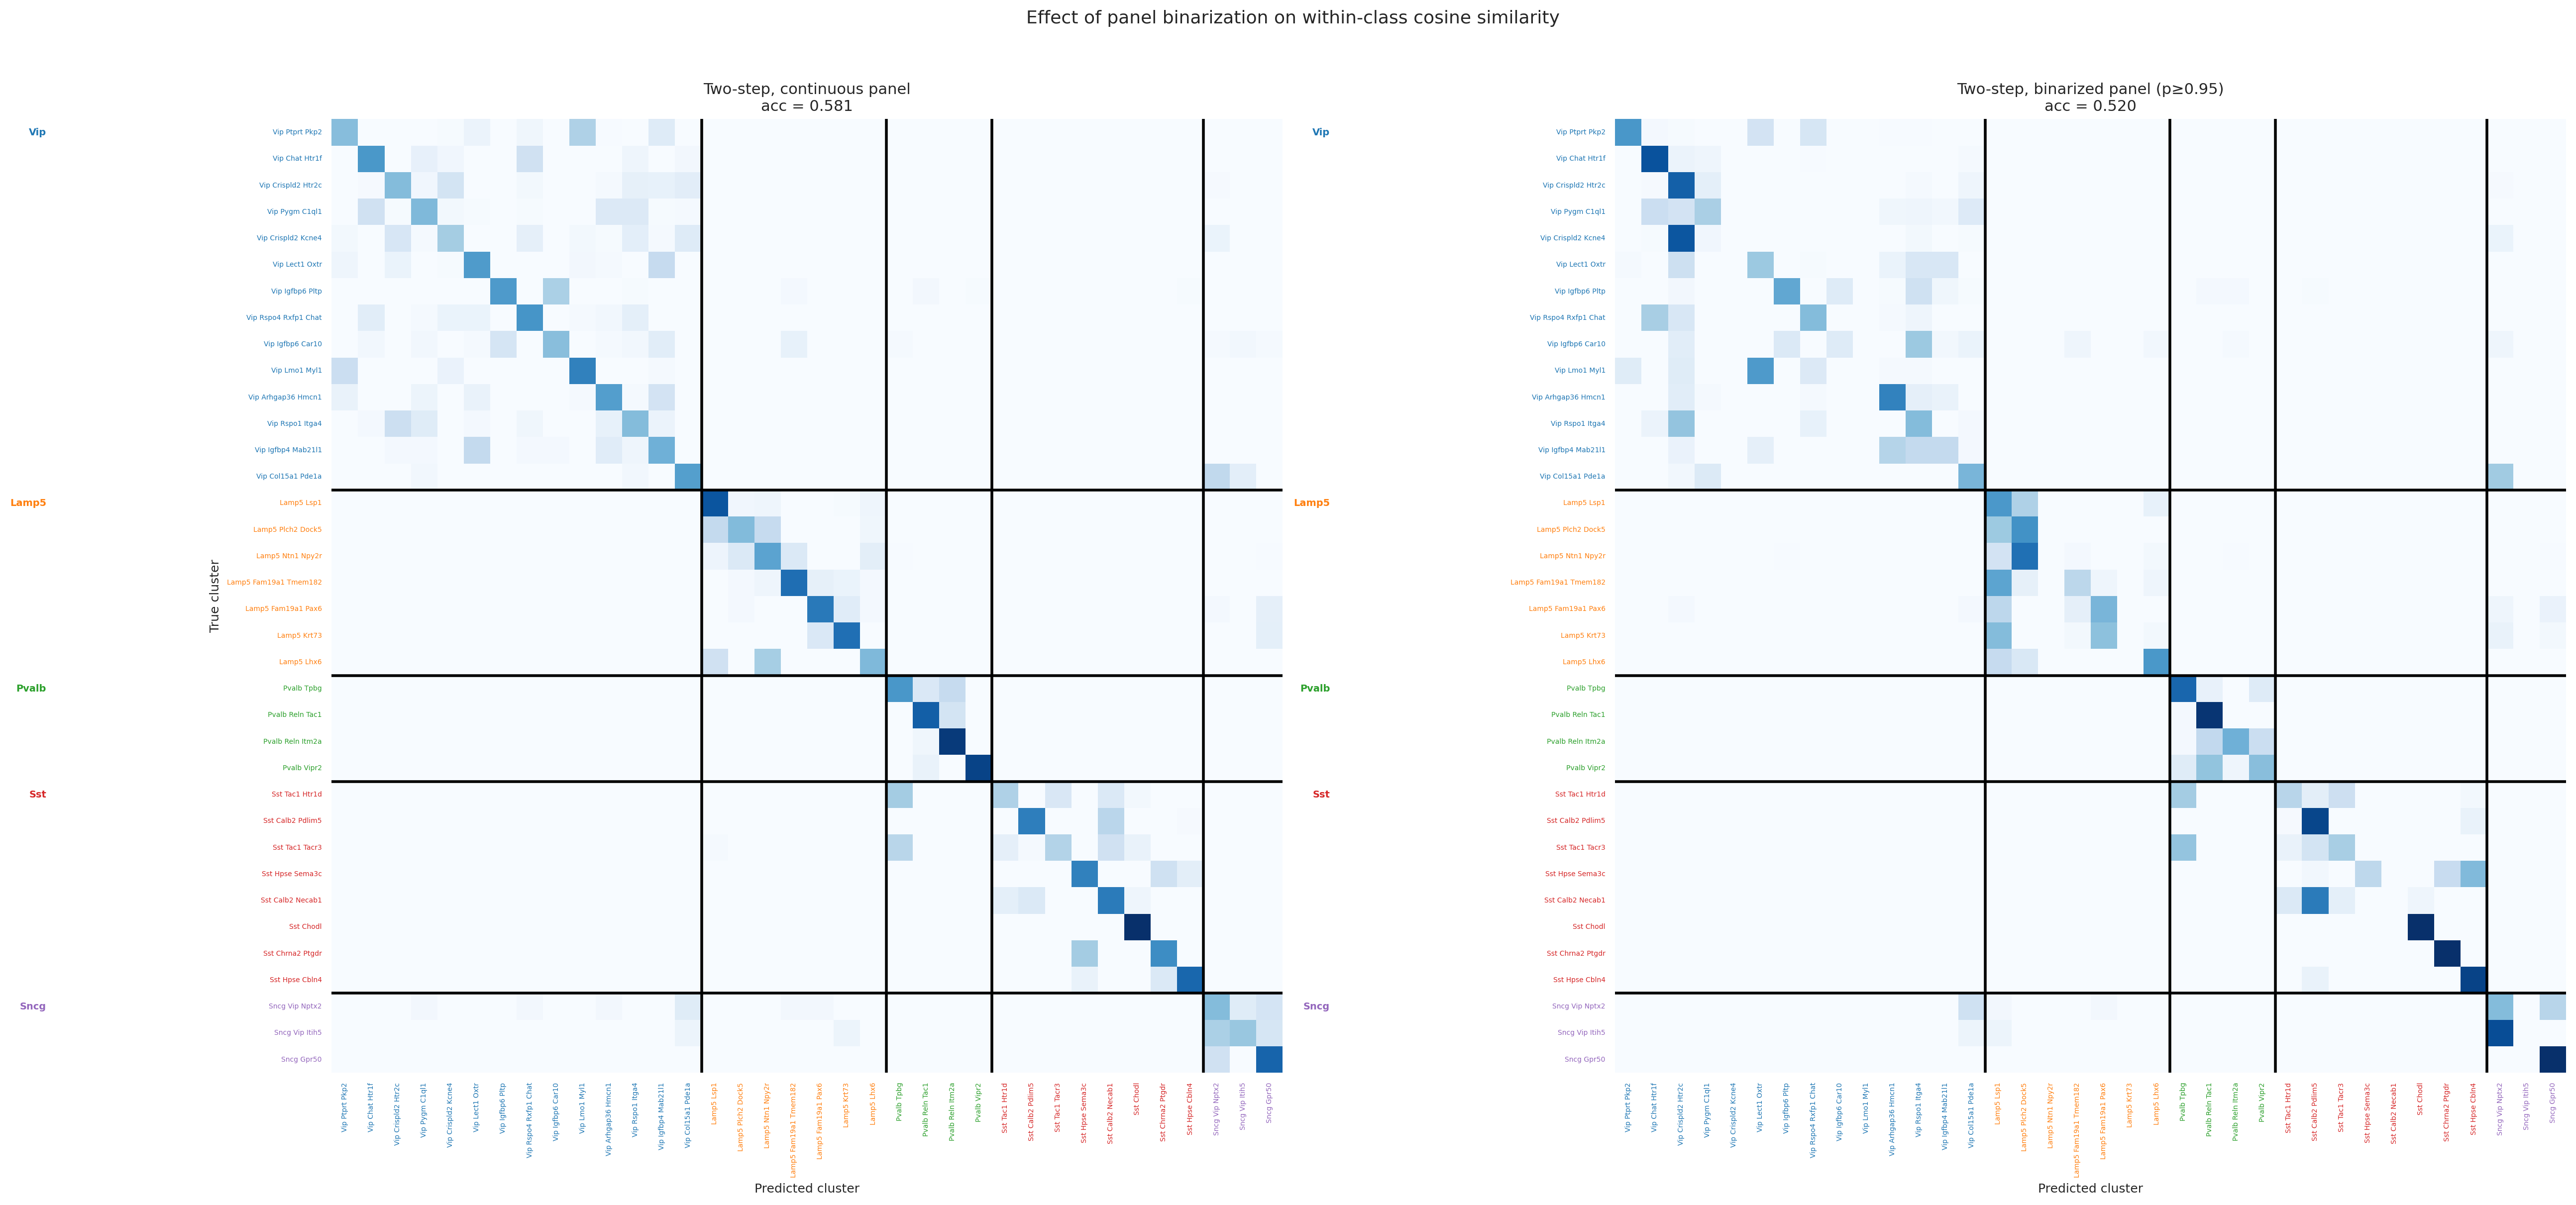

In [118]:
## Effect of binarizing the full panel: continuous vs binarized cosine (Step 2)
binarize_panel = True
# ── Run two-step with all panel genes binarized ───────────────────────────────
_, pred_cluster_bin = classify_two_step(
    adata_l23_inh,
    ref_medians,
    cluster_order_ref,
    cluster_to_subclass_ref,
    panel_ids,
    symbol_to_id,
    gmm_thresholds95,
    cardinal_genes=CARDINAL_GENES,
    binarize_panel=binarize_panel,
)

pred_cl_bin = pred_cluster_bin[valid_cell_mask]

# ── Confusion matrices ────────────────────────────────────────────────────────
conf_cont = pd.DataFrame(0, index=cluster_order_ref, columns=cluster_order_ref)
for t, p in zip(true_clusters, pred_cl_v):
    conf_cont.loc[t, p] += 1
conf_cont_norm = conf_cont.div(conf_cont.sum(axis=1), axis=0)

conf_bin = pd.DataFrame(0, index=cluster_order_ref, columns=cluster_order_ref)
for t, p in zip(true_clusters, pred_cl_bin):
    conf_bin.loc[t, p] += 1
conf_bin_norm = conf_bin.div(conf_bin.sum(axis=1), axis=0)

acc_cont = (pred_cl_v   == true_clusters).mean()
acc_bin  = (pred_cl_bin == true_clusters).mean()

print(f"Two-step, continuous panel : acc = {acc_cont:.3f}")
print(f"Two-step, binarized panel  : acc = {acc_bin:.3f}")

# ── Side-by-side figure ───────────────────────────────────────────────────────
fig, (ax_cont, ax_bin) = plt.subplots(1, 2, figsize=(26, 12))

draw_conf_heatmap(
    ax_cont, conf_cont_norm,
    f'Two-step, continuous panel\nacc = {acc_cont:.3f}',
    show_ylabel=True, show_cbar=False,
)
draw_conf_heatmap(
    ax_bin, conf_bin_norm,
    f'Two-step, binarized panel (p≥0.95)\nacc = {acc_bin:.3f}',
    show_ylabel=False, show_cbar=False,
)

plt.suptitle(
    'Effect of panel binarization on within-class cosine similarity',
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.show()

In-hand panel: 12 genes — Chat, Tac1, Crh, Gad2, Penk, Pdyn, Calb2, Lamp5, Cck, Sst, Pvalb, Vip
Two-step (binarized), full panel  (20 genes) : acc = 0.520
Two-step (binarized), in-hand     (12 genes) : acc = 0.474


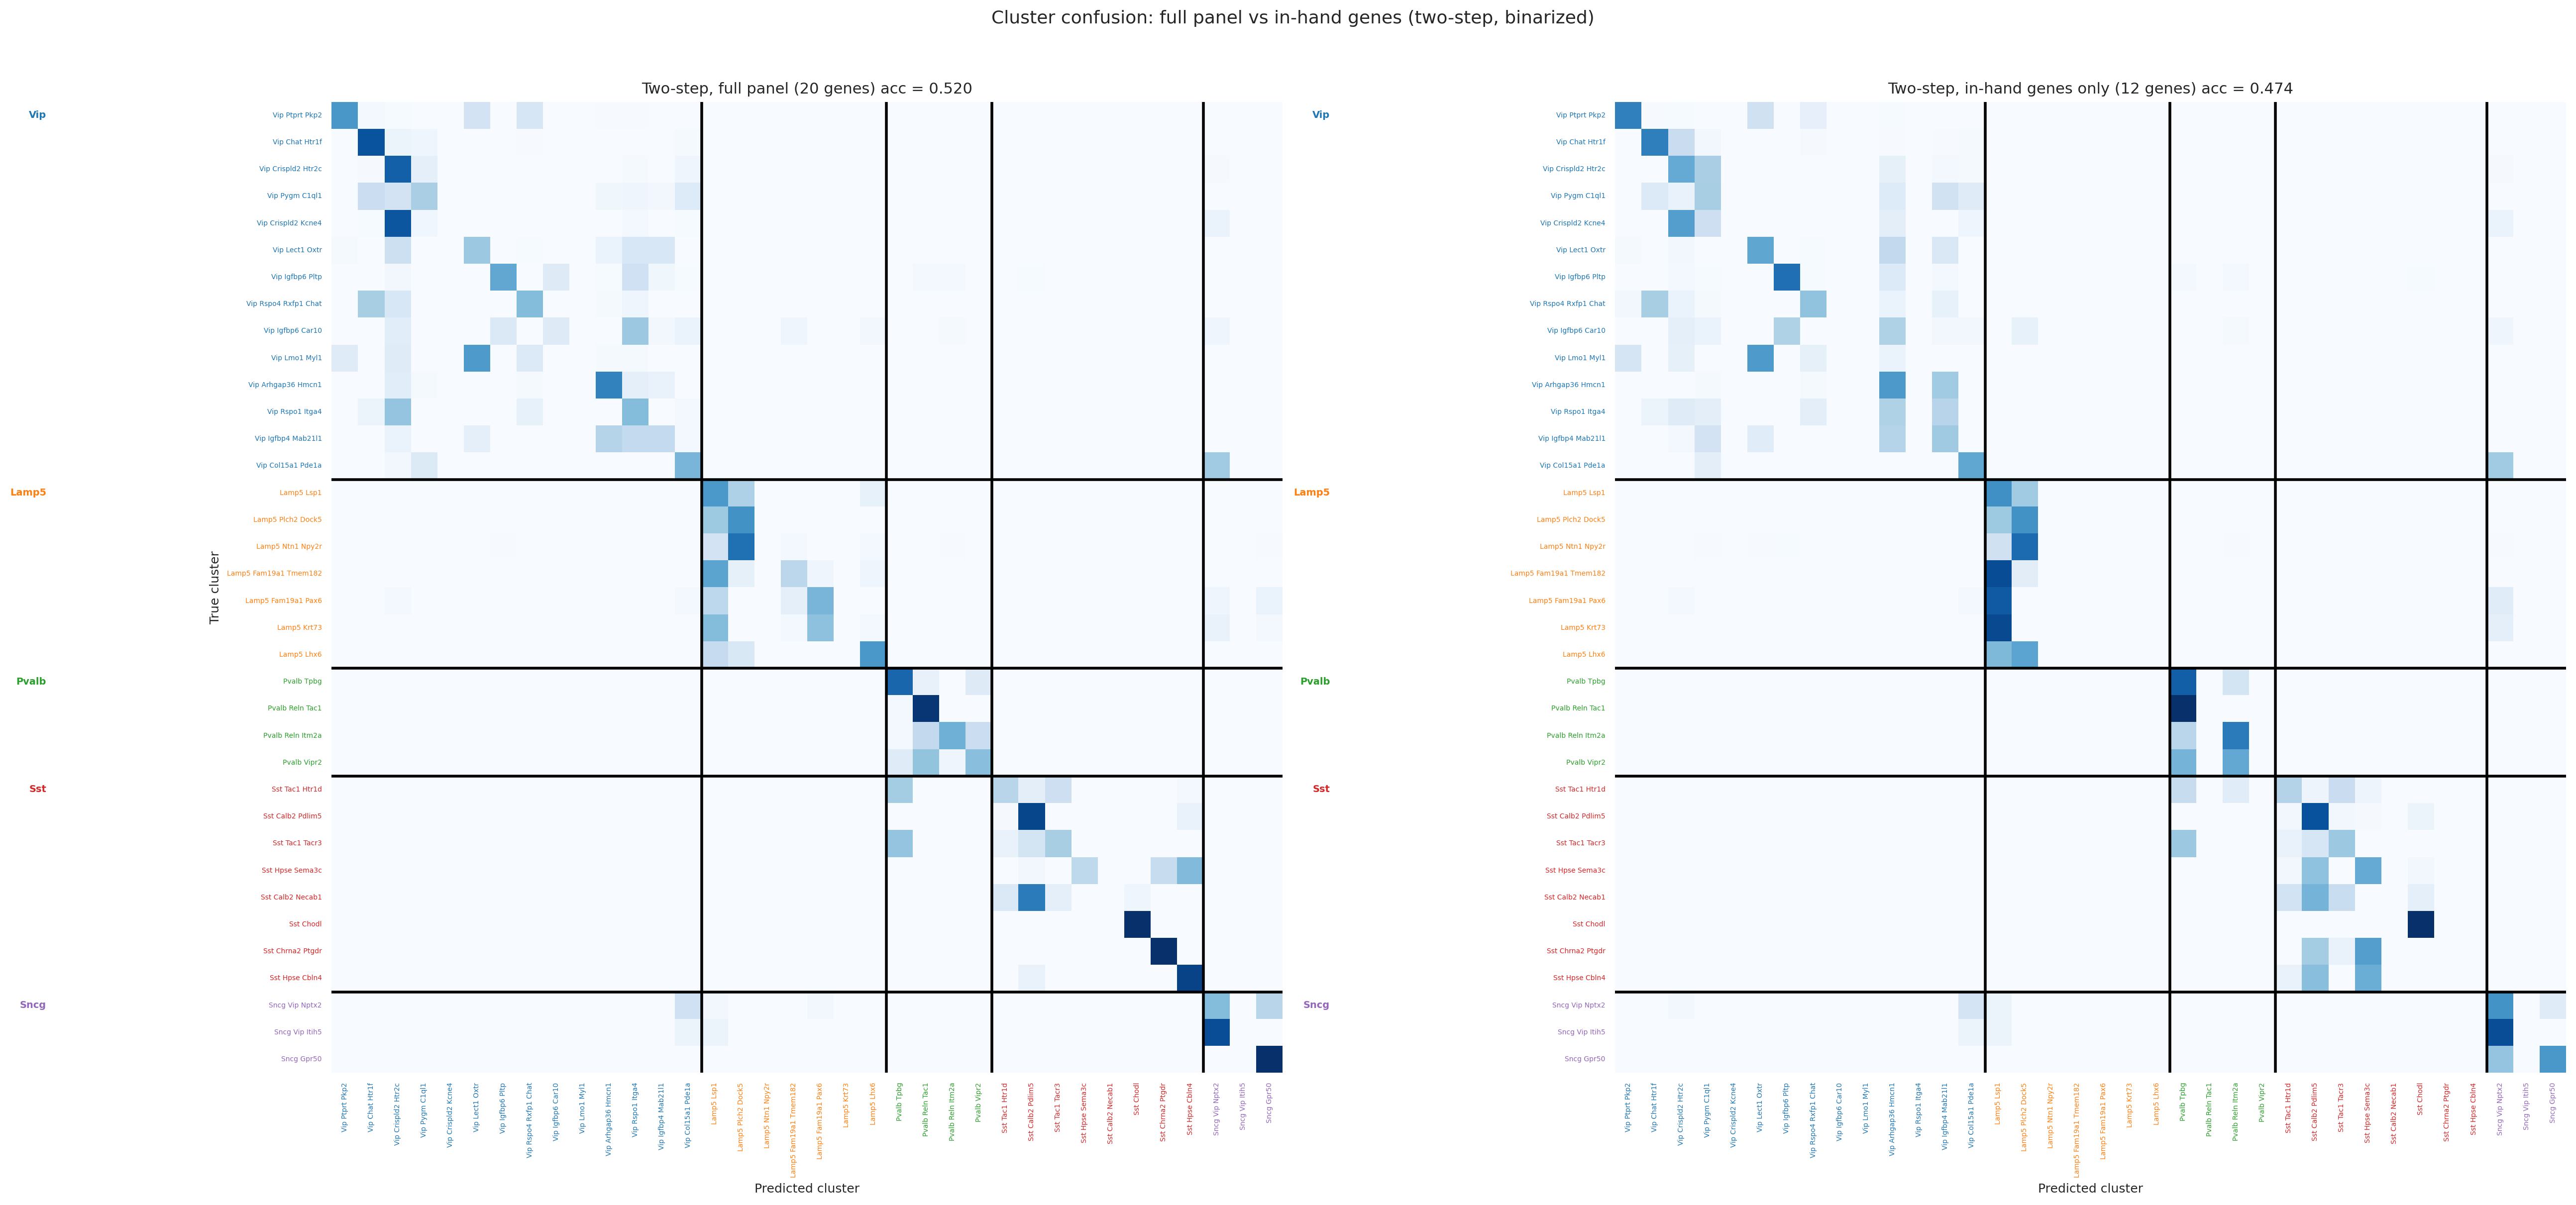

In [121]:
## In-hand gene subset: full panel vs genes already in hand
binarize_panel = True

IN_HAND_GENES = [
    'Chat', 'Tac1', 'Crh', 'Gad2', 'Penk', 'Pdyn',
    'Calb2', 'Lamp5', 'Cck', 'Sst', 'Pvalb', 'Vip',
]

in_hand_ids    = [symbol_to_id[g] for g in IN_HAND_GENES if g in symbol_to_id.index]
in_hand_labels = [g for g in IN_HAND_GENES if g in symbol_to_id.index]
missing_ih     = [g for g in IN_HAND_GENES if g not in symbol_to_id.index]
if missing_ih:
    print(f"WARNING — not found in dataset: {missing_ih}")
print(f"In-hand panel: {len(in_hand_ids)} genes — {', '.join(in_hand_labels)}")

method_str = 'binarized' if binarize_panel else 'continuous'

# ── Full panel (re-run with same binarize setting for fair comparison) ────────
_, pred_cluster_full_bp = classify_two_step(
    adata_l23_inh,
    ref_medians,
    cluster_order_ref,
    cluster_to_subclass_ref,
    panel_ids,
    symbol_to_id,
    gmm_thresholds95,
    cardinal_genes=CARDINAL_GENES,
    binarize_panel=binarize_panel,
)
pred_cl_full_bp = pred_cluster_full_bp[valid_cell_mask]

# ── In-hand panel ─────────────────────────────────────────────────────────────
_, pred_cluster_ih = classify_two_step(
    adata_l23_inh,
    ref_medians,
    cluster_order_ref,
    cluster_to_subclass_ref,
    in_hand_ids,
    symbol_to_id,
    gmm_thresholds95,
    cardinal_genes=CARDINAL_GENES,
    binarize_panel=binarize_panel,
)
pred_cl_ih = pred_cluster_ih[valid_cell_mask]

# ── Confusion matrices ────────────────────────────────────────────────────────
conf_full_p = pd.DataFrame(0, index=cluster_order_ref, columns=cluster_order_ref)
for t, p in zip(true_clusters, pred_cl_full_bp):
    conf_full_p.loc[t, p] += 1
conf_full_p_norm = conf_full_p.div(conf_full_p.sum(axis=1), axis=0)

conf_ih = pd.DataFrame(0, index=cluster_order_ref, columns=cluster_order_ref)
for t, p in zip(true_clusters, pred_cl_ih):
    conf_ih.loc[t, p] += 1
conf_ih_norm = conf_ih.div(conf_ih.sum(axis=1), axis=0)

acc_full_p = (pred_cl_full_bp == true_clusters).mean()
acc_ih     = (pred_cl_ih      == true_clusters).mean()

print(f"Two-step ({method_str}), full panel  ({len(panel_ids):2d} genes) : acc = {acc_full_p:.3f}")
print(f"Two-step ({method_str}), in-hand     ({len(in_hand_ids):2d} genes) : acc = {acc_ih:.3f}")

# ── Figure ────────────────────────────────────────────────────────────────────
fig, (ax_full, ax_ih) = plt.subplots(1, 2, figsize=(26, 12))

draw_conf_heatmap(
    ax_full, conf_full_p_norm,
    f'Two-step, full panel ({len(panel_ids)} genes) acc = {acc_full_p:.3f}',
    show_ylabel=True, show_cbar=False,
)
draw_conf_heatmap(
    ax_ih, conf_ih_norm,
    f'Two-step, in-hand genes only ({len(in_hand_ids)} genes) acc = {acc_ih:.3f}',
    show_ylabel=False, show_cbar=False,
)

plt.suptitle(
    f'Cluster confusion: full panel vs in-hand genes (two-step, {method_str})',
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.show()

Missing genes (9): ['Sncg', 'Reln', 'Tac2', 'Calb1', 'Mme', 'Ndnf', 'Hpse', 'Pthlh', 'Npy']
Starting panel (12 genes): ['Chat', 'Tac1', 'Crh', 'Gad2', 'Penk', 'Pdyn', 'Calb2', 'Lamp5', 'Cck', 'Sst', 'Pvalb', 'Vip']

Baseline (12 genes): acc = 0.474
 Per-class       Vip     Lamp5     Pvalb       Sst      Sncg
               0.451     0.413     0.661     0.463     0.435

  +Npy         acc = 0.494  (13 genes)      0.474     0.435     0.673     0.480     0.435
  +Reln        acc = 0.510  (14 genes)      0.474     0.435     0.762     0.497     0.435
  +Tac2        acc = 0.522  (15 genes)      0.494     0.450     0.762     0.497     0.403
  +Ndnf        acc = 0.526  (16 genes)      0.500     0.457     0.762     0.497     0.403
  +Hpse        acc = 0.527  (17 genes)      0.500     0.457     0.762     0.507     0.403
  +Mme         acc = 0.529  (18 genes)      0.499     0.457     0.762     0.527     0.403
  +Sncg        acc = 0.529  (19 genes)      0.499     0.457     0.762     0.527     0.40

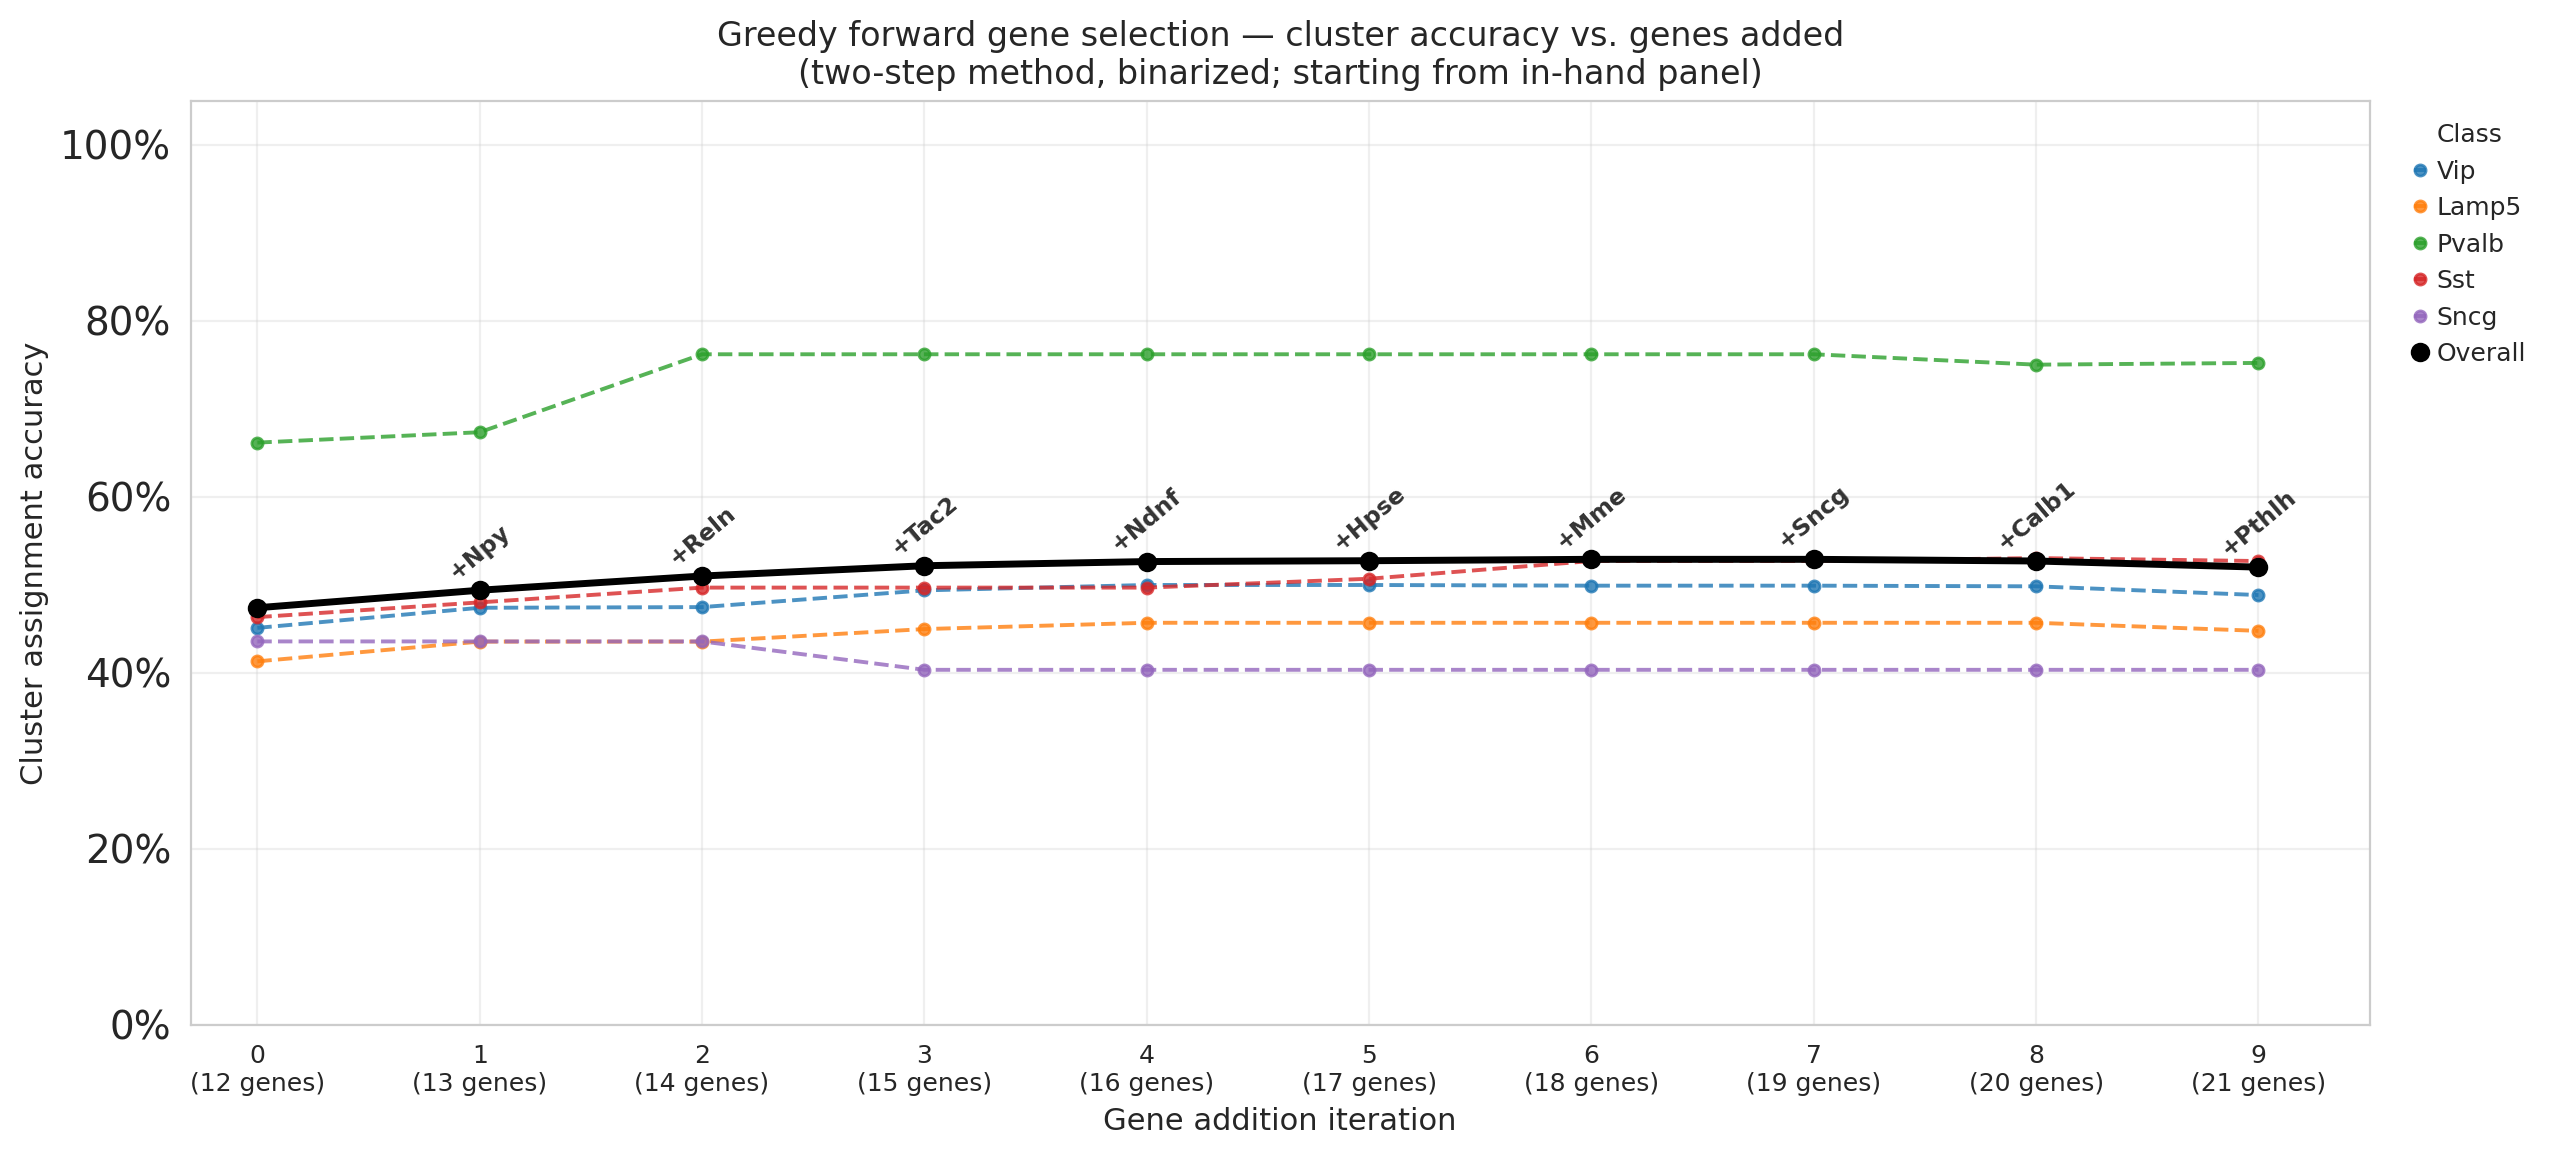

In [122]:
## Greedy forward gene selection: which missing genes to prioritize

binarize_panel = True

# ── Identify missing genes (in full panel but not yet in-hand) ───────────────
IN_HAND_SET   = set(IN_HAND_GENES)
MISSING_GENES = [g for g in PANEL_GENES if g not in IN_HAND_SET]
print(f"Missing genes ({len(MISSING_GENES)}): {MISSING_GENES}")
print(f"Starting panel ({len(in_hand_labels)} genes): {in_hand_labels}\n")

# ── Helper: run two-step classification and return overall + per-class accuracy
def compute_accuracy_for_panel(gene_list):
    gene_ids = [symbol_to_id[g] for g in gene_list if g in symbol_to_id.index]
    _, pred_cluster = classify_two_step(
        adata_l23_inh, ref_medians, cluster_order_ref, cluster_to_subclass_ref,
        gene_ids, symbol_to_id, gmm_thresholds95,
        cardinal_genes=CARDINAL_GENES, binarize_panel=binarize_panel,
    )
    pred_cl  = pred_cluster[valid_cell_mask]
    overall  = (pred_cl == true_clusters).mean()
    per_class = {
        sc: (pred_cl[true_subclass == sc] == true_clusters[true_subclass == sc]).mean()
        if (true_subclass == sc).sum() > 0 else np.nan
        for sc in subclass_order_ref
    }
    return overall, per_class

# ── Greedy forward selection ──────────────────────────────────────────────────
prospective_in_hand_panel = list(in_hand_labels)   # starts as a copy of in-hand genes
remaining = list(MISSING_GENES)

base_acc, base_per_class = compute_accuracy_for_panel(prospective_in_hand_panel)
overall_accs   = [base_acc]
per_class_accs = {sc: [base_per_class[sc]] for sc in subclass_order_ref}
added_genes    = ['baseline']
n_start        = len(prospective_in_hand_panel)

print(f"Baseline ({n_start} genes): acc = {base_acc:.3f}")
print(f"{'Per-class':>10}  " + "  ".join(f"{sc:>8}" for sc in subclass_order_ref))
print(" " * 12 + "  ".join(f"{base_per_class[sc]:>8.3f}" for sc in subclass_order_ref))
print()

while remaining:
    best_gene, best_acc, best_pc = None, -np.inf, None
    for candidate in remaining:
        acc, pc = compute_accuracy_for_panel(prospective_in_hand_panel + [candidate])
        if acc > best_acc:
            best_acc, best_gene, best_pc = acc, candidate, pc

    prospective_in_hand_panel.append(best_gene)
    remaining.remove(best_gene)
    overall_accs.append(best_acc)
    for sc in subclass_order_ref:
        per_class_accs[sc].append(best_pc[sc])
    added_genes.append(best_gene)
    n_total = len(prospective_in_hand_panel)
    pc_str  = "  ".join(f"{best_pc[sc]:>8.3f}" for sc in subclass_order_ref)
    print(f"  +{best_gene:<10}  acc = {best_acc:.3f}  ({n_total} genes)   {pc_str}")

print(f"\nFinal priority order of missing genes:")
for i, g in enumerate(added_genes[1:], 1):
    print(f"  {i}. {g}")

# ── Line plot ─────────────────────────────────────────────────────────────────
class_palette = dict(zip(subclass_order_ref, sns.color_palette('tab10', len(subclass_order_ref))))
x = np.arange(len(overall_accs))

fig, ax = plt.subplots(figsize=(13, 6))

# Per-class dashed accuracy lines
for sc in subclass_order_ref:
    yvals = per_class_accs[sc]
    ax.plot(x, yvals, color=class_palette[sc],
            linewidth=1.4, linestyle='--', alpha=0.8, label=sc, marker='o',
            markersize=4)

# Overall bold line
ax.plot(x, overall_accs, color='black', linewidth=2.5, marker='o',
        markersize=6, label='Overall', zorder=5)

# Annotate each added gene above the overall accuracy point
for i in range(1, len(added_genes)):
    ax.text(i, overall_accs[i] + 0.007, f'+{added_genes[i]}',
            ha='center', va='bottom', fontsize=8.5, rotation=40,
            fontweight='bold', color='#333333')

# X-axis: iteration index + gene count
xlabels = [f'{i}\n({n_start + i} genes)' for i in range(len(overall_accs))]
ax.set_xticks(x)
ax.set_xticklabels(xlabels, fontsize=9)

ax.set_xlabel('Gene addition iteration', fontsize=11)
ax.set_ylabel('Cluster assignment accuracy', fontsize=11)
ax.set_title(
    'Greedy forward gene selection — cluster accuracy vs. genes added\n'
    f'(two-step method, {"binarized" if binarize_panel else "continuous"}; starting from in-hand panel)',
    fontsize=12,
)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9,
          frameon=False, title='Class', title_fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_xlim(-0.3, len(x) - 0.5)
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))

plt.tight_layout()
plt.show()

Full panel       : 20 genes — ['Sst', 'Pvalb', 'Vip', 'Lamp5', 'Sncg', 'Cck', 'Chat', 'Tac1', 'Crh', 'Penk', 'Pdyn', 'Calb2', 'Reln', 'Tac2', 'Calb1', 'Mme', 'Ndnf', 'Hpse', 'Pthlh', 'Npy']
Protected (never dropped): ['Lamp5', 'Pvalb', 'Sst', 'Vip']
Droppable        : 16 genes — ['Sncg', 'Cck', 'Chat', 'Tac1', 'Crh', 'Penk', 'Pdyn', 'Calb2', 'Reln', 'Tac2', 'Calb1', 'Mme', 'Ndnf', 'Hpse', 'Pthlh', 'Npy']



Baseline (20 genes): acc = 0.520
 Per-class       Vip     Lamp5     Pvalb       Sst      Sncg
               0.488     0.448     0.752     0.530     0.403

  -Pthlh       acc = 0.522  (19 genes)      0.487     0.457     0.750     0.523     0.403
  -Pdyn        acc = 0.529  (18 genes)      0.487     0.471     0.750     0.554     0.403
  -Mme         acc = 0.527  (17 genes)      0.488     0.471     0.746     0.534     0.403
  -Hpse        acc = 0.530  (16 genes)      0.500     0.471     0.746     0.517     0.403
  -Calb1       acc = 0.528  (15 genes)      0.499     0.457     0.762     0.517     0.403
  -Ndnf        acc = 0.526  (14 genes)      0.499     0.450     0.762     0.517     0.403
  -Sncg        acc = 0.521  (13 genes)      0.487     0.450     0.762     0.517     0.403
  -Tac2        acc = 0.515  (12 genes)      0.484     0.435     0.762     0.517     0.403
  -Crh         acc = 0.494  (11 genes)      0.434     0.435     0.762     0.517     0.371
  -Chat        acc = 0.476  (10 ge

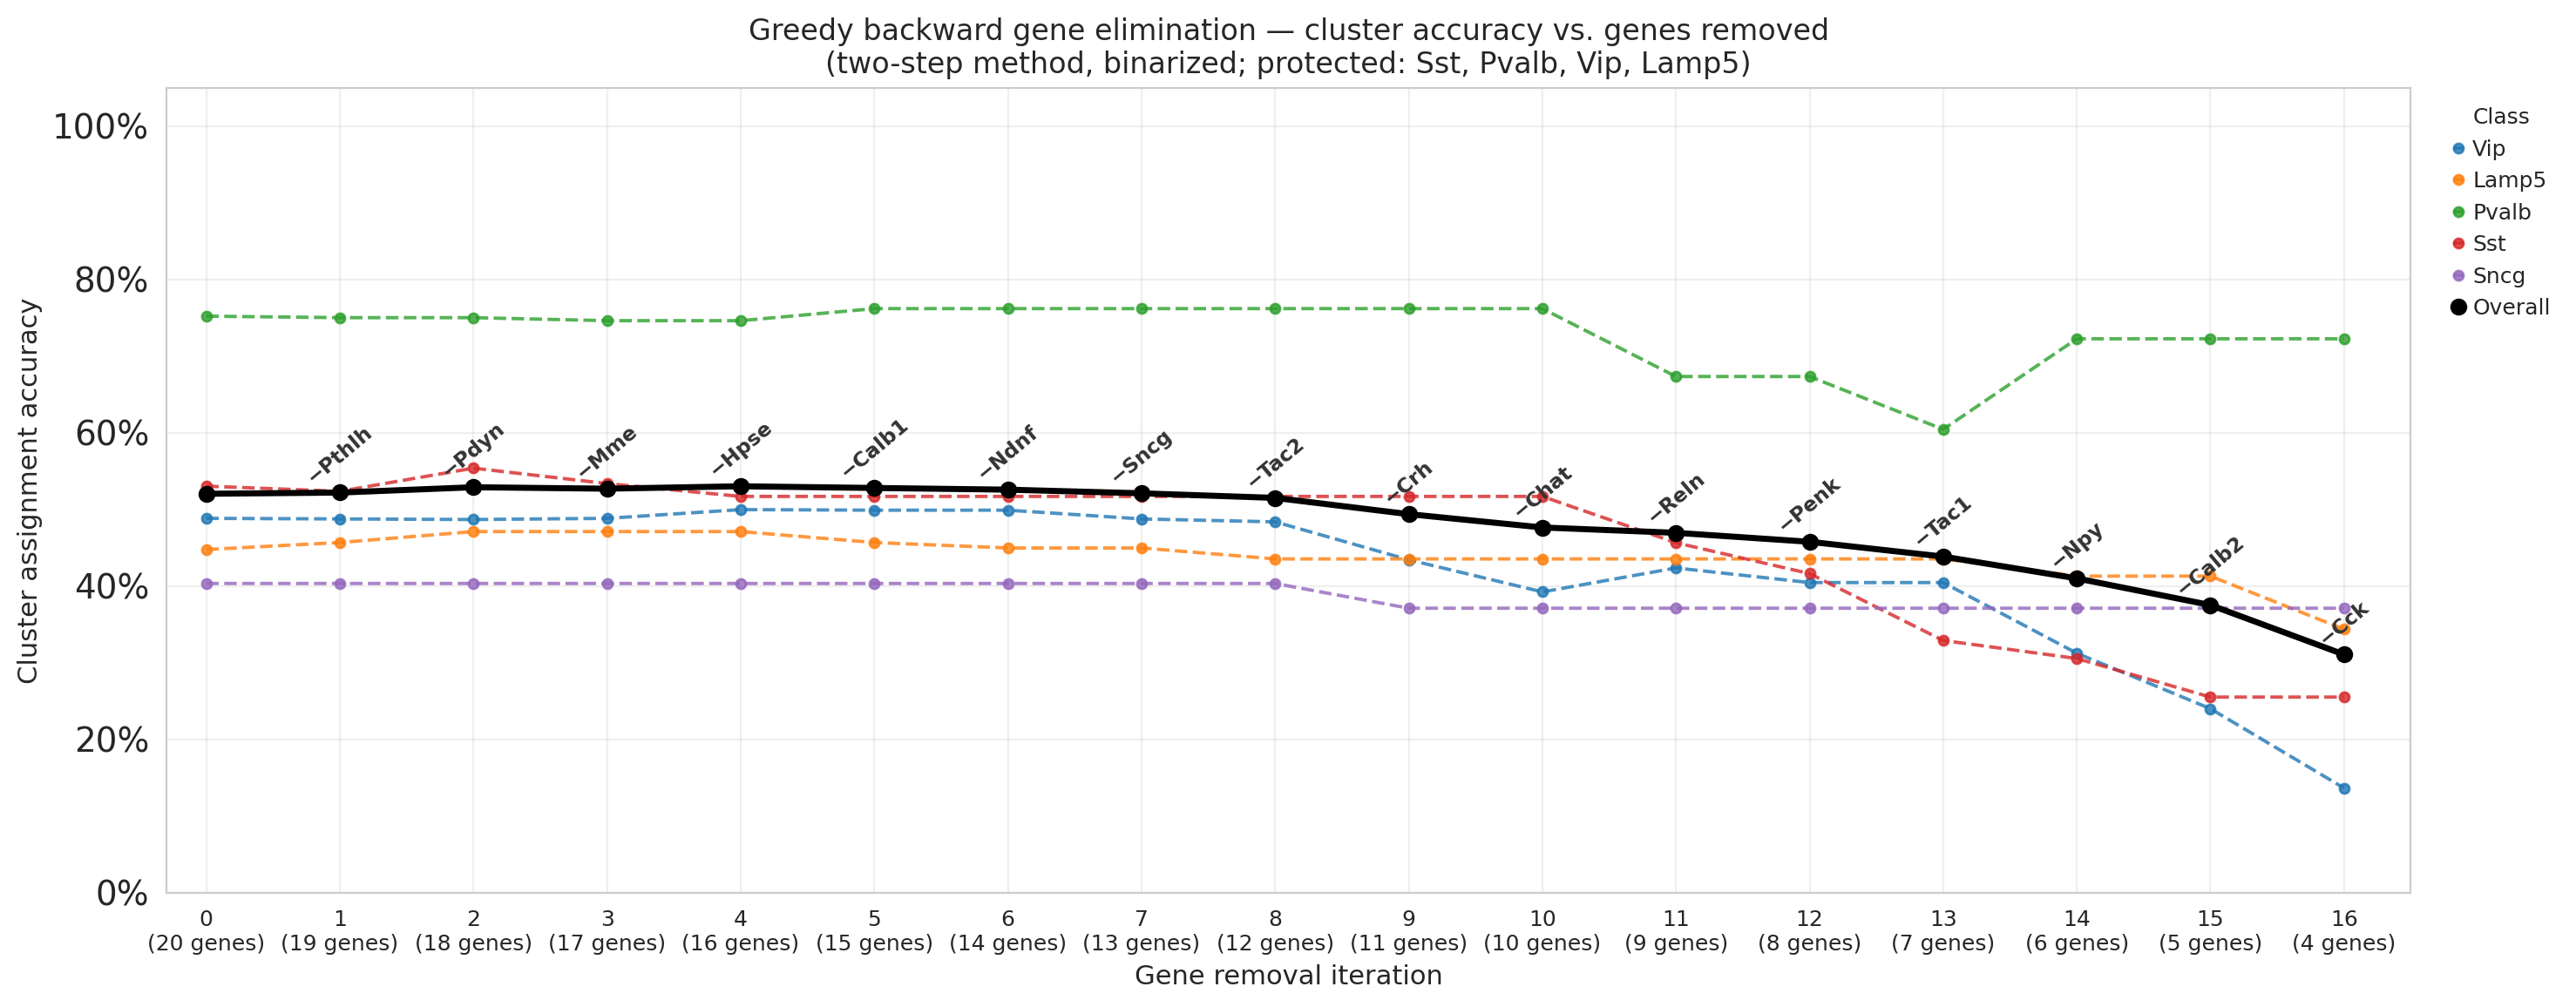

In [123]:
## Greedy backward gene elimination: starting from full panel, stopping at protected cardinal genes
binarize_panel = True


# ── Protected genes — never dropped (cardinal in-hand only) ──────────────────
PROTECTED_GENES = {'Sst', 'Pvalb', 'Vip', 'Lamp5'}
droppable = [g for g in panel_labels if g not in PROTECTED_GENES]

print(f"Full panel       : {len(panel_labels)} genes — {panel_labels}")
print(f"Protected (never dropped): {sorted(PROTECTED_GENES)}")
print(f"Droppable        : {len(droppable)} genes — {droppable}\n")

# ── Baseline: full 20-gene panel ──────────────────────────────────────────────
current_panel = list(panel_labels)

top_acc, top_pc = compute_accuracy_for_panel(current_panel)
drop_overall_accs   = [top_acc]
drop_per_class_accs = {sc: [top_pc[sc]] for sc in subclass_order_ref}
dropped_genes       = ['baseline']
remaining_drop      = list(droppable)

print(f"Baseline ({len(current_panel)} genes): acc = {top_acc:.3f}")
print(f"{'Per-class':>10}  " + "  ".join(f"{sc:>8}" for sc in subclass_order_ref))
print(" " * 12 + "  ".join(f"{top_pc[sc]:>8.3f}" for sc in subclass_order_ref))
print()

while remaining_drop:
    # Try dropping each remaining non-protected gene; keep the least-damaging removal
    best_gene, best_acc, best_pc = None, -np.inf, None
    for candidate in remaining_drop:
        trial = [g for g in current_panel if g != candidate]
        acc, pc = compute_accuracy_for_panel(trial)
        if acc > best_acc:
            best_acc, best_gene, best_pc = acc, candidate, pc

    current_panel.remove(best_gene)
    remaining_drop.remove(best_gene)
    drop_overall_accs.append(best_acc)
    for sc in subclass_order_ref:
        drop_per_class_accs[sc].append(best_pc[sc])
    dropped_genes.append(best_gene)
    n_left  = len(current_panel)
    pc_str  = "  ".join(f"{best_pc[sc]:>8.3f}" for sc in subclass_order_ref)
    print(f"  -{best_gene:<10}  acc = {best_acc:.3f}  ({n_left} genes)   {pc_str}")

print(f"\nFinal panel (protected only): {current_panel}")
print(f"\nDrop order (least-damaging first):")
for i, g in enumerate(dropped_genes[1:], 1):
    print(f"  {i}. {g}")

# ── Line plot ─────────────────────────────────────────────────────────────────
n_full = len(panel_labels)
x      = np.arange(len(drop_overall_accs))

fig, ax = plt.subplots(figsize=(15, 6))

# Per-class dashed accuracy lines
for sc in subclass_order_ref:
    ax.plot(x, drop_per_class_accs[sc], color=class_palette[sc],
            linewidth=1.4, linestyle='--', alpha=0.8, label=sc, marker='o',
            markersize=4)

# Overall bold line
ax.plot(x, drop_overall_accs, color='black', linewidth=2.5, marker='o',
        markersize=6, label='Overall', zorder=5)

# Annotate each dropped gene above the overall accuracy point
for i in range(1, len(dropped_genes)):
    ax.text(i, drop_overall_accs[i] + 0.007, f'−{dropped_genes[i]}',
            ha='center', va='bottom', fontsize=8.5, rotation=40,
            fontweight='bold', color='#333333')

# X-axis: iteration index + remaining gene count
xlabels = [f'{i}\n({n_full - i} genes)' for i in range(len(drop_overall_accs))]
ax.set_xticks(x)
ax.set_xticklabels(xlabels, fontsize=9)

ax.set_xlabel('Gene removal iteration', fontsize=11)
ax.set_ylabel('Cluster assignment accuracy', fontsize=11)
ax.set_title(
    'Greedy backward gene elimination — cluster accuracy vs. genes removed\n'
    f'(two-step method, {"binarized" if binarize_panel else "continuous"}; protected: Sst, Pvalb, Vip, Lamp5)',
    fontsize=12,
)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9,
          frameon=False, title='Class', title_fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_xlim(-0.3, len(x) - 0.5)
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))

plt.tight_layout()
plt.show()

/tmp/ipykernel_697616/243912246.py:26: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(sst_clusters_ordered, rotation=35, ha='right', fontsize=8)


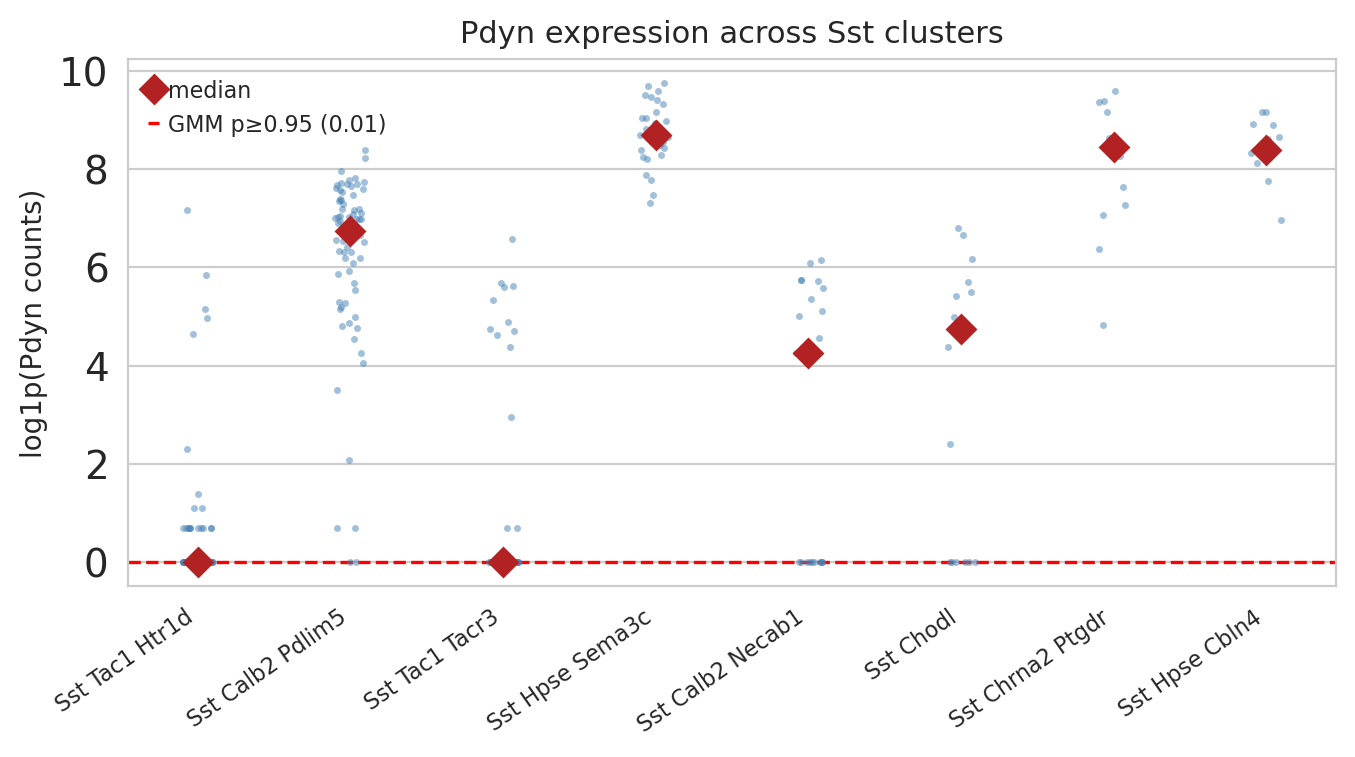


Median log1p(Pdyn) per Sst cluster:
  Sst Hpse Sema3c                      median=8.69  Pdyn+ cells=100%  (n=29)
  Sst Chrna2 Ptgdr                     median=8.45  Pdyn+ cells=100%  (n=14)
  Sst Hpse Cbln4                       median=8.38  Pdyn+ cells=100%  (n=14)
  Sst Calb2 Pdlim5                     median=6.74  Pdyn+ cells=97%  (n=70)
  Sst Chodl                            median=4.74  Pdyn+ cells=65%  (n=17)
  Sst Calb2 Necab1                     median=4.26  Pdyn+ cells=52%  (n=21)
  Sst Tac1 Htr1d                       median=0.00  Pdyn+ cells=26%  (n=78)
  Sst Tac1 Tacr3                       median=0.00  Pdyn+ cells=24%  (n=55)


In [124]:
## Pdyn expression across Sst clusters

pdyn_id  = symbol_to_id['Pdyn']
pdyn_col = adata_l23_inh.var_names.get_loc(pdyn_id)

sst_mask    = adata_l23_inh.obs['cluster'].isin(
    [c for c in cluster_order_ref if cluster_to_subclass_ref[c] == 'Sst']
)
obs_sst     = adata_l23_inh.obs.loc[sst_mask, 'cluster'].copy()
pdyn_counts = np.log1p(X[sst_mask, pdyn_col])

sst_clusters_ordered = [c for c in cluster_order_ref if cluster_to_subclass_ref[c] == 'Sst']

df_sst = pd.DataFrame({'cluster': obs_sst.values, 'log1p_Pdyn': pdyn_counts})
medians = df_sst.groupby('cluster')['log1p_Pdyn'].median().reindex(sst_clusters_ordered)

fig, ax = plt.subplots(figsize=(7, 4))
sns.stripplot(data=df_sst, x='cluster', y='log1p_Pdyn', order=sst_clusters_ordered,
              color='steelblue', size=2.5, alpha=0.5, jitter=True, ax=ax)
ax.plot(range(len(sst_clusters_ordered)), medians.values,
        'D', color='firebrick', markersize=7, zorder=5, label='median')

pdyn_t95 = gmm_thresholds95['Pdyn']
ax.axhline(pdyn_t95, color='red', linewidth=1.2, linestyle='--', label=f'GMM p≥0.95 ({pdyn_t95:.2f})')

ax.set_xticklabels(sst_clusters_ordered, rotation=35, ha='right', fontsize=8)
ax.set_xlabel('')
ax.set_ylabel('log1p(Pdyn counts)', fontsize=10)
ax.set_title('Pdyn expression across Sst clusters', fontsize=11)
ax.legend(fontsize=8, frameon=False)
plt.tight_layout()
plt.show()

print("\nMedian log1p(Pdyn) per Sst cluster:")
for c, v in medians.sort_values(ascending=False).items():
    n = (obs_sst == c).sum()
    pct_pos = (df_sst.loc[df_sst['cluster'] == c, 'log1p_Pdyn'] > pdyn_t95).mean() * 100
    print(f"  {c:<35}  median={v:.2f}  Pdyn+ cells={pct_pos:.0f}%  (n={n})")

Scale diagnostic (cell 0):
  Gene        binary  raw_log  norm_log
  Sst         0.00    0.00     0.00
  Pvalb       0.00    0.00     0.00
  Vip         1.00    11.10     0.91
  Lamp5       0.00    0.00     0.00
  Sncg        0.00    0.00     0.00
  Cck         0.00    0.00     0.00
  Chat        0.00    0.00     0.00
  Tac1        0.00    0.00     0.00

L2 norm — all binary: 2.24
L2 norm — Vip raw continuous: 11.28  (Vip log1p = 11.10)
L2 norm — Vip norm continuous: 2.20  (Vip norm  = 0.91)

All-binarized baseline: overall acc = 0.520
  Sst         delta_acc = -0.0095   Vip=+0.000  Lamp=-0.023  Pval=+0.000  Sst=-0.023  Sncg=+0.000
  Pvalb       delta_acc = -0.0019   Vip=+0.000  Lamp=+0.000  Pval=+0.000  Sst=-0.023  Sncg=+0.016
  Vip         delta_acc = -0.0139   Vip=-0.024  Lamp=-0.006  Pval=+0.000  Sst=-0.023  Sncg=+0.016
  Lamp5       delta_acc = -0.0028   Vip=-0.001  Lamp=-0.008  Pval=+0.000  Sst=+0.000  Sncg=+0.000
  Sncg        delta_acc = +0.0013   Vip=+0.000  Lamp=+0.000  Pval=

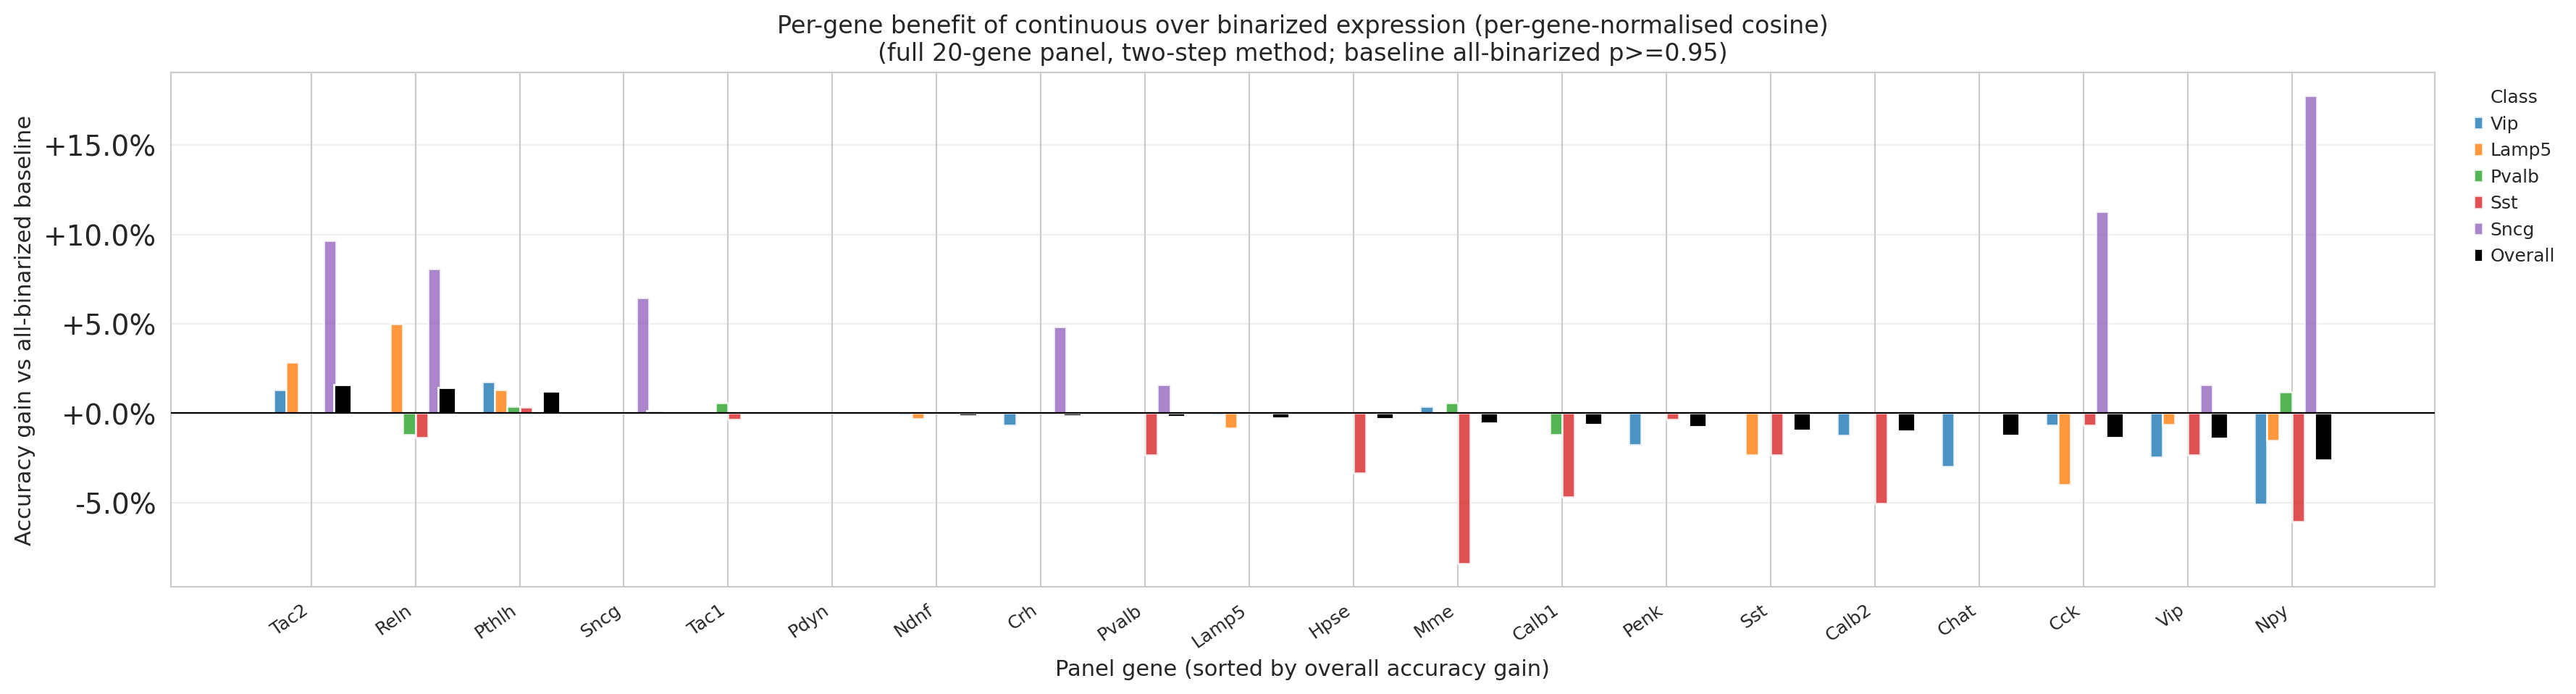

In [126]:
## Per-gene accuracy gain from switching to continuous expression (full panel)
# Baseline: all panel genes binarized (p>=0.95).
# For each gene in turn, replace its binarized column with continuous log1p counts.
# Reports accuracy gain vs the all-binarized baseline.
#
# IMPORTANT — per-gene normalization:
# Cosine similarity is scale-sensitive. Mixing one continuous gene (values 0-8)
# with 19 binary genes (values 0-1) lets the continuous gene dominate the dot
# product proportional to its absolute magnitude, rather than its discriminative
# pattern. Fix: divide each gene column by its max across cells+reference before
# computing cosine similarity, putting all genes on the same [0,1] scale.

from sklearn.metrics.pairwise import cosine_similarity as cos_sim

# -- Pre-build panel matrices once --------------------------------------------
X_dense = adata_l23_inh.layers['counts']
if hasattr(X_dense, 'toarray'):
    X_dense = X_dense.toarray()

p_cols  = [adata_l23_inh.var_names.get_loc(gid) for gid in panel_ids]
X_log   = np.log1p(X_dense[:, p_cols])              # (n_cells,  n_panel)
ref_log = np.log1p(ref_medians[panel_ids].values)   # (n_clusters, n_panel)

# Per-gene max across both cells and reference centroids — used for normalisation
gene_max = np.maximum(X_log.max(axis=0), ref_log.max(axis=0))
gene_max  = np.where(gene_max == 0, 1.0, gene_max)  # avoid /0 for silent genes

X_log_norm   = X_log   / gene_max        # continuous values scaled to [0,1]
ref_log_norm = ref_log / gene_max

X_bin    = binarize_expression(X_log,   panel_labels, gmm_thresholds95)
ref_bin  = binarize_expression(ref_log, panel_labels, gmm_thresholds95)

# -- Diagnostic: confirm scale mismatch in raw mixing -------------------------
print("Scale diagnostic (cell 0):")
print(f"  {'Gene':<10}  binary  raw_log  norm_log")
for j, g in enumerate(panel_labels[:8]):
    print(f"  {g:<10}  {X_bin[0,j]:.2f}    {X_log[0,j]:.2f}     {X_log_norm[0,j]:.2f}")
raw_vec   = X_bin[0].copy(); raw_vec[2]  = X_log[0, 2]        # Vip (high expresser) raw
norm_vec  = X_bin[0].copy(); norm_vec[2] = X_log_norm[0, 2]   # Vip normalised
print(f"\nL2 norm — all binary: {np.linalg.norm(X_bin[0]):.2f}")
print(f"L2 norm — Vip raw continuous: {np.linalg.norm(raw_vec):.2f}  "
      f"(Vip log1p = {X_log[0,2]:.2f})")
print(f"L2 norm — Vip norm continuous: {np.linalg.norm(norm_vec):.2f}  "
      f"(Vip norm  = {X_log_norm[0,2]:.2f})")

# -- Step 1 class assignments (binarized cardinal -- shared across all runs) --
pred_class_s1, _ = classify_two_step(
    adata_l23_inh, ref_medians, cluster_order_ref, cluster_to_subclass_ref,
    panel_ids, symbol_to_id, gmm_thresholds95,
    cardinal_genes=CARDINAL_GENES, binarize_panel=True,
)

s1_subclass_idx = {}
for idx, c in enumerate(cluster_order_ref):
    s1_subclass_idx.setdefault(cluster_to_subclass_ref[c], []).append(idx)

def run_step2(X_q, ref):
    pred = np.empty(len(pred_class_s1), dtype=object)
    for sc, idxs in s1_subclass_idx.items():
        mask = pred_class_s1 == sc
        if not mask.any():
            continue
        sim  = cos_sim(X_q[mask], ref[idxs])
        pred[mask] = [cluster_order_ref[idxs[b]] for b in sim.argmax(axis=1)]
    unknown = pred_class_s1 == 'Unknown'
    if unknown.any():
        sim  = cos_sim(X_q[unknown], ref)
        pred[unknown] = [cluster_order_ref[b] for b in sim.argmax(axis=1)]
    return pred

def acc_overall_and_per_class(pred):
    pred_v = pred[valid_cell_mask]
    overall = (pred_v == true_clusters).mean()
    per_class = {
        sc: (pred_v[true_subclass == sc] == true_clusters[true_subclass == sc]).mean()
        for sc in subclass_order_ref
    }
    return overall, per_class

# -- Baseline: all binarized --------------------------------------------------
pred_base = run_step2(X_bin, ref_bin)
base_overall, base_per_class = acc_overall_and_per_class(pred_base)
print(f"\nAll-binarized baseline: overall acc = {base_overall:.3f}")

# -- Per-gene swap: replace one gene's column with per-gene-normalised log counts
gene_gains = {}
for j, gene in enumerate(panel_labels):
    X_mix   = X_bin.copy();   X_mix[:, j]  = X_log_norm[:, j]
    ref_mix = ref_bin.copy(); ref_mix[:, j] = ref_log_norm[:, j]
    pred    = run_step2(X_mix, ref_mix)
    overall, per_class = acc_overall_and_per_class(pred)
    gene_gains[gene] = {
        'overall':   overall - base_overall,
        'per_class': {sc: per_class[sc] - base_per_class[sc] for sc in subclass_order_ref},
    }
    print(f"  {gene:<10}  delta_acc = {overall - base_overall:+.4f}   "
          + "  ".join(f"{sc[:4]}={per_class[sc]-base_per_class[sc]:+.3f}"
                      for sc in subclass_order_ref))

# -- Sort genes by overall gain -----------------------------------------------
sorted_genes = sorted(panel_labels, key=lambda g: gene_gains[g]['overall'], reverse=True)

# -- Grouped bar plot ---------------------------------------------------------
n_genes   = len(sorted_genes)
n_classes = len(subclass_order_ref)
bar_w     = 0.12
offsets   = (np.arange(n_classes + 1) - n_classes / 2) * bar_w

fig, ax = plt.subplots(figsize=(18, 5))
x = np.arange(n_genes)

for k, sc in enumerate(subclass_order_ref):
    gains = [gene_gains[g]['per_class'][sc] for g in sorted_genes]
    ax.bar(x + offsets[k], gains, width=bar_w, color=class_palette[sc],
           alpha=0.80, label=sc, zorder=3)

overall_gains = [gene_gains[g]['overall'] for g in sorted_genes]
ax.bar(x + offsets[-1], overall_gains, width=bar_w * 1.4, color='black',
       label='Overall', zorder=4)

ax.axhline(0, color='black', linewidth=0.8, zorder=5)
ax.set_xticks(x)
ax.set_xticklabels(sorted_genes, rotation=35, ha='right', fontsize=9)
ax.set_xlabel('Panel gene (sorted by overall accuracy gain)', fontsize=11)
ax.set_ylabel('Accuracy gain vs all-binarized baseline', fontsize=11)
ax.set_title(
    'Per-gene benefit of continuous over binarized expression (per-gene-normalised cosine)\n'
    f'(full {len(panel_labels)}-gene panel, two-step method; baseline all-binarized p>=0.95)',
    fontsize=12,
)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:+.1%}'))
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9,
          frameon=False, title='Class', title_fontsize=9)
ax.grid(axis='y', alpha=0.3, zorder=0)
plt.tight_layout()
plt.show()
